In [2]:
# ===============================
# Core imports (required for training)
# ===============================
import os
import numpy as np
import zarr
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, List


# ===============================
# Paths & templates (used by dataset + training)
# ===============================
ZARR_DISP  = "displacements.zarr"
ZARR_SDV   = "ip_growth_elem.zarr"               # lambda_g_x, lambda_g_y latents
ZARR_VOL   = "expd_volumes.zarr"
DESIGN_ZARR_PATH = "Design_and_Metadata.zarr"

U_LATENT_TEMPLATE = "latent_displ_r{r}/coeffs"

from pathlib import Path
NODES_CSV = str(Path("GOH_Nodes_Test_for_Visualization.csv").resolve())
ELEMS_CSV = str(Path("GOH_Elements_Test_for_Visualization.csv").resolve())

# --- Displacement POD + snapshot path info (adjust names if needed) ---
DISP_POD_GROUP       = "pod_full"     # inside displacements.zarr
DISP_POD_U_NAME      = "U"            # dataset with basis vectors
DISP_POD_MEAN_NAME   = "mean"         # dataset with mean
DISP_SNAP_DATASET    = "snapshots"    # full-order snapshots in displacements.zarr

# ===============================
# Training hyperparameters
# ===============================
BATCH_SIZE   = 256
LR           = 1e-3
SEED         = 123

CTRL_DIM   = 1   # volume setpoint
PARAM_DIM  = 7   # design params

# Nominal timestep (used only for rollouts / metadata)
FIXED_DT   = 1.4


# ===============================
# Reproducibility
# ===============================
def set_seed(seed: int = SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE


In [4]:
import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    # Debug: check it really reduced 2 layers -> 1 per cell
    # Count elements per cell (should be 2 for most cells in a 2-layer mesh)
    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    # For debugging: centroid (x,y) per cell (from selected bottom element)
    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,          # (Ne,)
    H: int, W: int,
    bottom_elem_idx: np.ndarray,   # (H*W,)
):
    """
    Convert an element field vector (Ne,) into a bottom-surface grid image (H,W)
    by selecting vec_elem at bottom_elem_idx for each cell.
    """
    flat = vec_elem[bottom_elem_idx]          # (H*W,)
    return flat.reshape(H, W)


In [5]:
H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys = (
    build_bottom_surface_elem_grid_mapping(
        nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
        elems_csv="GOH_Elements_Test_for_Visualization.csv",
        tol_xy=1e-8,
    )
)

print("\n=== GRID CHECK ===")
print(f"H = {H}")
print(f"W = {W}")
print(f"H * W = {H * W}")
print(f"bottom_elem_idx shape = {bottom_elem_idx.shape}")

[bottom mapping] Ne=7200, grid H=60, W=60, H*W=3600
[bottom mapping] per-cell counts: min=2, max=2, unique occupied cells=3600
[bottom mapping] selected bottom elems: 3600 (should equal H*W)

=== GRID CHECK ===
H = 60
W = 60
H * W = 3600
bottom_elem_idx shape = (3600,)


In [6]:
import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements
      (this is the only assumption that cannot be broken by file ordering)

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)     node IDs corresponding to node_xyz_bot rows
      elem_node_ids_bot : (Ne_bot,4) original node IDs for debugging
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    # bottom layer = second half of element rows
    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]   # (Ne_bot, 4)

    # bottom node IDs = unique node IDs referenced by bottom elements
    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    # pull those nodes from nodes_csv
    # (use a dict for fast lookup by ID)
    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    # build bottom node table, sorted by node_id
    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    # map node_id -> local index [0..Nbot-1]
    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    # remap element connectivity to local indices
    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot


In [7]:
def load_raw_data(r_modes: int):
    """
    Load raw data for a given r_modes (per field).
    Returns:
        U_lat        : (S, r)
        volume_snap  : (S,)   actual expander volume per snapshot
        G_field      : (S, 2, H, W) OR (S, 2, N)  (teacher-forced growth fields: x and y)
        sim_index    : (S,)
        time_vals    : (S,)
        volume_SP    : (S,)   volume setpoint per snapshot
        design_all   : (S, 7)
        n_sims       : int
    """
    from pathlib import Path

    g_disp   = zarr.open_group(ZARR_DISP, mode="r")
    g_design = zarr.open_group(DESIGN_ZARR_PATH, mode="r")
    g_sdv    = zarr.open_group(ZARR_SDV, mode="r")   # contains snaps_SDV1 and snaps_SDV4

    vol_root = Path(ZARR_VOL)

    u_path = U_LATENT_TEMPLATE.format(r=r_modes)
    U_lat = np.asarray(g_disp[u_path], dtype=np.float32).T  # (S, r)

    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals = np.asarray(mgrp["time_vals"], dtype=np.float64)

    volume_SP = np.asarray(
        zarr.open_array(str(vol_root / "volume_setpoint_per_snapshot"), mode="r"),
        dtype=np.float32
    )

    design_all = np.asarray(
        g_design["design_params_per_snapshot"], dtype=np.float32
    )

    S = U_lat.shape[0]
    assert sim_index.shape[0] == S == time_vals.shape[0]
    assert volume_SP.shape[0] == S == design_all.shape[0]

    volume_snap = np.asarray(
        zarr.open_array(str(vol_root / "expander_volume" / "cvol"), mode="r"),
        dtype=np.float32
    )
    if volume_snap.ndim != 1 or volume_snap.shape[0] != S:
        raise ValueError(f"Expected cvol as (S,) with S={S}, got shape {volume_snap.shape}")

    # -------- NEW: load growth fields (2 channels) and rasterize bottom surface --------
    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder("snaps_SDV1")   # expected (Ne, S) = (7200, 42237)
    Gy_raw = _load_snap_folder("snaps_SDV4")   # expected (Ne, S)

    # Make snapshot-major: (S, Ne)
    if Gx_raw.shape == (7200, S):
        Gx = Gx_raw.T
    else:
        Gx = Gx_raw
    if Gy_raw.shape == (7200, S):
        Gy = Gy_raw.T
    else:
        Gy = Gy_raw

    if Gx.shape[0] != S or Gy.shape[0] != S:
        raise ValueError(f"Growth fields must be snapshot-aligned with S={S}. Got Gx={Gx.shape}, Gy={Gy.shape}")

    Ne = Gx.shape[1]
    if Ne != 7200:
        print(f"[warn] Expected Ne=7200 from mesh, got Ne={Ne}. Proceeding anyway.")

    # Bottom-surface element selection mapping -> 60x60 grid
    H, W, bottom_idx = get_bottom_grid_cache()
    assert H * W == bottom_idx.shape[0], (H, W, bottom_idx.shape)

    # Rasterize bottom surface: (S, H, W)
    # Vectorized gather: bottom_idx selects elements for each (i,j) cell
    Gx_bot = Gx[:, bottom_idx].reshape(S, H, W)
    Gy_bot = Gy[:, bottom_idx].reshape(S, H, W)

    # Stack channels: (S, 2, H, W)
    G_field = np.stack([Gx_bot, Gy_bot], axis=1).astype(np.float32)

    print(f"  G_field bottom: {G_field.shape}  (S,2,H,W) with H={H}, W={W}")
    import matplotlib.pyplot as plt
    k = 1000
    #plt.figure(); plt.imshow(G_field[k,0], origin="lower"); plt.title("Gx bottom"); plt.colorbar(); plt.show()
    #plt.figure(); plt.imshow(G_field[k,1], origin="lower"); plt.title("Gy bottom"); plt.colorbar(); plt.show()

    # -------------------------------------------------------------------------------


    return (
        U_lat,
        volume_snap,
        G_field,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        len(np.unique(sim_index)),
    )


In [8]:
def compute_error_and_integral(volume_snap: np.ndarray,
                               volume_SP: np.ndarray,
                               sim_index: np.ndarray,
                               time_vals: np.ndarray):
    """
    Compute PI-style error and integral per snapshot.

    Args:
        volume_snap: (S,) expander volume at each snapshot (true)
        volume_SP:   (S,) volume setpoint at each snapshot
        sim_index:   (S,) which simulation each snapshot belongs to (0..n_sims-1)
        time_vals:   (S,) physical time of each snapshot [days]

    Returns:
        error:    (S,) e_k = SP_k - V_k
        integral: (S,) I_k = sum_{j<=k, same sim} e_j * dt_j  (piecewise per sim)
    """
    S = volume_snap.shape[0]
    assert volume_SP.shape[0] == S
    assert sim_index.shape[0] == S
    assert time_vals.shape[0] == S

    error = volume_SP - volume_snap           # (S,)
    integral = np.zeros_like(error, dtype=np.float64)

    # accumulate integral separately for each simulation
    for s in np.unique(sim_index):
        idx = np.where(sim_index == s)[0]
        if idx.size == 0:
            continue

        t_s = time_vals[idx]
        order = np.argsort(t_s)
        idx_sorted = idx[order]

        e_s = error[idx_sorted].astype(np.float64)
        I_s = np.zeros_like(e_s)

        # discrete integral: I_{k} = I_{k-1} + dt_{k-1} * e_{k-1}
        for k in range(1, e_s.shape[0]):
            dt_k = t_s[order][k] - t_s[order][k-1]
            I_s[k] = I_s[k-1] + dt_k * e_s[k-1]

        integral[idx_sorted] = I_s

    return error.astype(np.float32), integral.astype(np.float32)


In [9]:
def build_pairs_for_sims(
    sim_ids,
    Z_norm_all: np.ndarray,
    sp_norm_all: np.ndarray,
    design_norm_all: np.ndarray,
    e_norm_all: np.ndarray,
    I_norm_all: np.ndarray,
    Ag_norm_all: np.ndarray,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    dt_nominal: float = 1.4,
):
    """
    Build one-step pairs for sims in `sim_ids`.

    X_k    = [z_k_norm, e_k_norm, I_k_norm, SP_k_norm, Ag_k_norm, design_k_norm]
    Y_k    = z_{k+1}_norm
    DT_k   = t_{k+1} - t_k
    SNAP_k = snapshot index for time k
    """
    X_list, Y_list, DT_list, SNAP_list = [], [], [], []
    D_state = Z_norm_all.shape[1]

    for s in sim_ids:
        idx = np.where(sim_index == s)[0]
        if idx.size < 2:
            continue

        t_s = time_vals[idx]
        order = np.argsort(t_s)
        idx_sorted = idx[order]

        Zs       = Z_norm_all[idx_sorted, :]       # (T, D_state)
        SPs_n    = sp_norm_all[idx_sorted]         # (T,)
        PARAMs_n = design_norm_all[idx_sorted, :]  # (T, 7)
        Es_n     = e_norm_all[idx_sorted]          # (T,)
        Is_n     = I_norm_all[idx_sorted]          # (T,)
        AGs_n    = Ag_norm_all[idx_sorted]         # (T,)
        ts       = time_vals[idx_sorted]           # (T,)

        if Zs.shape[0] < 2:
            continue

        Z_t    = Zs[:-1, :]
        Z_next = Zs[1:, :]

        SP_t    = SPs_n[:-1].reshape(-1, 1)
        PARAM_t = PARAMs_n[:-1, :]
        E_t     = Es_n[:-1].reshape(-1, 1)
        I_t     = Is_n[:-1].reshape(-1, 1)
        Ag_t    = AGs_n[:-1].reshape(-1, 1)

        dt_s = (ts[1:] - ts[:-1]).astype(np.float32)
        if (not np.all(np.isfinite(dt_s))) or np.any(dt_s <= 0.0):
            bad = np.where((~np.isfinite(dt_s)) | (dt_s <= 0.0))[0][:10]
            raise ValueError(
                f"Non-positive or non-finite dt in sim {s}. "
                f"Example bad indices: {bad}, dt_s[bad]={dt_s[bad]}"
            )

        snap_k = idx_sorted[:-1].astype(np.int64)

        X_s = np.concatenate([Z_t, E_t, I_t, SP_t, Ag_t, PARAM_t], axis=1)
        Y_s = Z_next

        X_list.append(X_s)
        Y_list.append(Y_s)
        DT_list.append(dt_s)
        SNAP_list.append(snap_k)

    if len(X_list) == 0:
        return None, None, None, None, D_state

    X = np.vstack(X_list).astype(np.float32)
    Y = np.vstack(Y_list).astype(np.float32)
    DT = np.concatenate(DT_list).astype(np.float32)
    SNAP = np.concatenate(SNAP_list).astype(np.int64)

    print(
        "  build_pairs_for_sims:",
        "X", X.shape,
        "Y", Y.shape,
        "DT", DT.shape,
        "SNAP", SNAP.shape,
        f"(dt_nominal={dt_nominal})"
    )

    return X, Y, DT, SNAP, D_state

In [26]:
import torch
from torch.utils.data import Dataset
import numpy as np

class LatentVelocityDataset(Dataset):
    def __init__(self, X, Y, DT):
        """
        Dataset for NODE on z = [u_latents, volume].

        X  : (N, D_in)    input features
        Y  : (N, D_state) target state = z_{k+1}_norm
        DT : (N,)         per-pair time step in days
        """
        self.X  = X.astype(np.float32)
        self.Y  = Y.astype(np.float32)
        self.DT = DT.astype(np.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x  = torch.from_numpy(self.X[idx])     # (D_in,)
        y  = torch.from_numpy(self.Y[idx])     # (D_state,)
        dt = torch.tensor(self.DT[idx], dtype=torch.float32)  # scalar
        return x, y, dt

In [27]:
class VelocityNet(nn.Module):
    def __init__(self,
                 dim_state: int,
                 dim_sp: int = 1,
                 dim_design: int = 7,
                 dim_error: int = 1,
                 dim_integral: int = 1,
                 dim_ag: int = 1,
                 hidden: int = 128):
        super().__init__()

        # store this so downstream code can access it
        self.dim_state = dim_state

        input_dim = dim_state + dim_sp + dim_design + dim_error + dim_integral + dim_ag

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, dim_state),
        )

    def forward(self, x):
        return self.net(x)

In [28]:
def prepare_dataset(r_modes: int, val_fraction: float = 0.2):
    dt_nominal = 1.4

    (U_lat,
     volume_snap, G_field,
     sim_index, time_vals,
     volume_SP, design_all,
     n_sims) = load_raw_data(r_modes)

    error_all, integral_all = compute_error_and_integral(
        volume_snap=volume_snap,
        volume_SP=volume_SP,
        sim_index=sim_index,
        time_vals=time_vals,
    )

    unique_sims = np.unique(sim_index)
    np.random.shuffle(unique_sims)

    n_val = max(1, int(val_fraction * len(unique_sims)))
    val_sims   = unique_sims[:n_val]
    train_sims = unique_sims[n_val:]

    train_mask = np.isin(sim_index, train_sims)

    print(f"[prepare_dataset r={r_modes}] n_sims={len(unique_sims)}, "
          f"train_sims={len(train_sims)}, val_sims={len(val_sims)}")

    Z_state_all = np.concatenate(
        [U_lat.astype(np.float32), volume_snap.reshape(-1, 1).astype(np.float32)],
        axis=1
    )
    D_state = Z_state_all.shape[1]

    def mean_std_train(x, mask, axis=0, keepdims=True, eps=1e-8):
        xm = x[mask]
        mean = xm.mean(axis=axis, keepdims=keepdims)
        std  = xm.std(axis=axis, keepdims=keepdims) + eps
        return mean, std

    z_mean, z_std = mean_std_train(Z_state_all, train_mask, axis=0, keepdims=True)
    Z_norm_all = ((Z_state_all - z_mean) / z_std).astype(np.float32)

    sp_mean, sp_std = mean_std_train(volume_SP.reshape(-1, 1), train_mask, axis=0, keepdims=True)
    sp_norm_all = ((volume_SP.reshape(-1, 1) - sp_mean) / sp_std).reshape(-1).astype(np.float32)

    design_mean, design_std = mean_std_train(design_all, train_mask, axis=0, keepdims=True)
    design_norm_all = ((design_all - design_mean) / design_std).astype(np.float32)

    e_mean, e_std = mean_std_train(error_all.reshape(-1, 1), train_mask, axis=0, keepdims=True)
    e_norm_all = ((error_all.reshape(-1, 1) - e_mean) / e_std).reshape(-1).astype(np.float32)

    I_mean, I_std = mean_std_train(integral_all.reshape(-1, 1), train_mask, axis=0, keepdims=True)
    I_norm_all = ((integral_all.reshape(-1, 1) - I_mean) / I_std).reshape(-1).astype(np.float32)

    # ---- load snapshot-aligned Ag_net and normalize it (TRAIN stats only) ----
    zg = zarr.open("ip_growth_elem.zarr", mode="r")
    Ag_net_all = np.asarray(zg["derived"]["Ag_net"][:], dtype=np.float32).reshape(-1)

    if Ag_net_all.shape[0] != sim_index.shape[0]:
        raise ValueError(
            f"Ag_net_all must be snapshot-aligned. Got {Ag_net_all.shape[0]} vs sim_index {sim_index.shape[0]}"
        )

    ag_mean, ag_std = mean_std_train(Ag_net_all.reshape(-1, 1), train_mask, axis=0, keepdims=True)
    Ag_norm_all = ((Ag_net_all.reshape(-1, 1) - ag_mean) / ag_std).reshape(-1).astype(np.float32)

    norm_stats = {
        "z_mean": z_mean, "z_std": z_std,
        "sp_mean": sp_mean, "sp_std": sp_std,
        "design_mean": design_mean, "design_std": design_std,
        "e_mean": e_mean, "e_std": e_std,
        "I_mean": I_mean, "I_std": I_std,
        "ag_mean": ag_mean, "ag_std": ag_std,
    }

    X_train, Y_train, DT_train, SNAP_train, D_state_out = build_pairs_for_sims(
        train_sims,
        Z_norm_all,
        sp_norm_all,
        design_norm_all,
        e_norm_all,
        I_norm_all,
        Ag_norm_all,
        sim_index,
        time_vals,
        dt_nominal=dt_nominal
    )

    expected_input_dim = D_state_out + 1 + 1 + 1 + 1 + 7
    assert X_train.shape[1] == expected_input_dim, (X_train.shape, expected_input_dim)

    X_val, Y_val, DT_val, SNAP_val, _ = build_pairs_for_sims(
        val_sims,
        Z_norm_all,
        sp_norm_all,
        design_norm_all,
        e_norm_all,
        I_norm_all,
        Ag_norm_all,
        sim_index,
        time_vals,
        dt_nominal=dt_nominal
    )

    aux_data = {
        "Z_state_all": Z_state_all.astype(np.float32),
        "Z_norm_all": Z_norm_all.astype(np.float32),
        "sim_index": sim_index,
        "time_vals": time_vals,
        "volume_SP": volume_SP,
        "design_all": design_all,
        "volume_snap": volume_snap,
        "Ag_net": Ag_net_all.astype(np.float32),
        "SNAP_train": SNAP_train,
        "SNAP_val": SNAP_val,
        "n_sims": n_sims,
        "train_sims": train_sims,
        "val_sims": val_sims,
        "dt_nominal": dt_nominal,
    }

    return (
        X_train, Y_train, DT_train, SNAP_train,
        X_val,   Y_val,   DT_val,   SNAP_val,
        D_state_out, dt_nominal, norm_stats, aux_data
    )

In [29]:
import torch

def eval_ablation_growth(model, loader, D_state, device, mode="none"):
    """
    Ag-input ablation for the scalar-Ag NODE:
      mode="none"    : use Ag input as-is
      mode="zero"    : set Ag input to zero
      mode="shuffle" : shuffle Ag input across the batch

    Assumes loader yields: (x, y, dt)
      x  : [B, D_in] where x = [z_state, e, I, SP, Ag, design]
      y  : [B, D_state]
      dt : [B]
    """
    model.eval()
    total_loss = 0.0
    n_total = 0

    # x layout: [z_state | e | I | SP | Ag | design]
    ag_col = D_state + 3

    with torch.no_grad():
        for xb, yb, dtb in loader:
            xb  = xb.to(device).float()
            yb  = yb.to(device).float()
            dtb = dtb.to(device).float()

            x_use = xb.clone()

            if mode == "zero":
                x_use[:, ag_col] = 0.0
            elif mode == "shuffle":
                perm = torch.randperm(x_use.size(0), device=device)
                x_use[:, ag_col] = x_use[perm, ag_col]
            elif mode == "none":
                pass
            else:
                raise ValueError(f"Unknown mode='{mode}'. Use 'none', 'zero', or 'shuffle'.")

            dz_pred = model(x_use)   # (B, D_state)
            z_t = x_use[:, :D_state]
            z_next_pred = z_t + dtb.unsqueeze(1) * dz_pred

            loss = (z_next_pred - yb).pow(2).mean()
            bs = xb.size(0)
            total_loss += loss.item() * bs
            n_total += bs

    return total_loss / max(n_total, 1)

In [30]:
import torch

def shape_function_gradients_torch(xi: float, eta: float, device=None, dtype=torch.float32):
    """
    Return dN_dxi, dN_deta as torch tensors of shape (4,) for bilinear Q4.
    Matches your numpy function exactly.
    """
    xi_t  = torch.tensor(float(xi),  device=device, dtype=dtype)
    eta_t = torch.tensor(float(eta), device=device, dtype=dtype)

    dN_dxi = torch.stack([
        -(1 - eta_t) / 4,
         (1 - eta_t) / 4,
         (1 + eta_t) / 4,
        -(1 + eta_t) / 4,
    ], dim=0)

    dN_deta = torch.stack([
        -(1 - xi_t) / 4,
        -(1 + xi_t) / 4,
         (1 + xi_t) / 4,
         (1 - xi_t) / 4,
    ], dim=0)

    return dN_dxi, dN_deta


In [31]:
import torch

def integrate_growth_torch(
    node_coords,     # (Nn, 3) torch
    elem_conn,       # (Ne, 4) torch long
    node_u,          # (Nn, 3) torch
    lamdag_elem,     # (Ne, 2) torch
    k1: float,
    k2: float,
    theta_crit: float,
    time: float,
    dt: float,
    xi: float = 0.0,
    eta: float = 0.0,
    eps: float = 1e-12,
):
    """
    Vectorized torch version of your integrate_growth loop.
    Returns updated lamdag_elem (Ne,2). Safe for autograd.
    """
    device = node_coords.device
    dtype  = node_coords.dtype

    # ---- gather element nodal data ----
    # X_e: (Ne, 4, 3), u_e: (Ne, 4, 3), x_e: (Ne, 4, 3)
    X_e = node_coords[elem_conn]
    u_e = node_u[elem_conn]
    x_e = X_e + u_e

    # ---- gradients at center (constants) ----
    dN_dxi, dN_deta = shape_function_gradients_torch(xi, eta, device=device, dtype=dtype)  # (4,), (4,)

    # ---- covariant basis in reference ----
    # Gxi = sum_a X_a * dN_a/dxi, similarly for eta
    # X_e.transpose(1,2): (Ne,3,4) @ (4,) -> (Ne,3)
    Gxi  = torch.matmul(X_e.transpose(1, 2), dN_dxi)   # (Ne, 3)
    Geta = torch.matmul(X_e.transpose(1, 2), dN_deta)  # (Ne, 3)

    # Normal N = cross(Gxi,Geta)/||cross||
    cross_ref = torch.cross(Gxi, Geta, dim=1)          # (Ne,3)
    N = cross_ref / (torch.linalg.norm(cross_ref, dim=1, keepdim=True) + eps)

    # Jacobian-like matrix G = [Gxi Geta N] as columns
    G = torch.stack([Gxi, Geta, N], dim=2)             # (Ne,3,3)
    G_inv = torch.linalg.inv(G)                        # (Ne,3,3)

    # dual basis = rows of G_inv
    G_dual_xi  = G_inv[:, 0, :]                        # (Ne,3)
    G_dual_eta = G_inv[:, 1, :]                        # (Ne,3)
    # G_dual_N   = G_inv[:, 2, :]                      # not used below

    # ---- covariant basis in deformed config ----
    gxi  = torch.matmul(x_e.transpose(1, 2), dN_dxi)   # (Ne,3)
    geta = torch.matmul(x_e.transpose(1, 2), dN_deta)  # (Ne,3)

    cross_def = torch.cross(gxi, geta, dim=1)          # (Ne,3)
    n = cross_def / (torch.linalg.norm(cross_def, dim=1, keepdim=True) + eps)

    # ---- build F (plane strain-ish): F = gxi ⊗ G^xi + geta ⊗ G^eta + n ⊗ N
    # outer(a,b) batched: (Ne,3,1)*(Ne,1,3) -> (Ne,3,3)
    def outer(a, b):
        return a.unsqueeze(2) * b.unsqueeze(1)

    F = outer(gxi, G_dual_xi) + outer(geta, G_dual_eta) + outer(n, N)  # (Ne,3,3)

    # ---- growth tensor Fg (diagonal in a0,s0,N basis with a0=[1,0,0], s0=[0,1,0]) ----
    lam1g = lamdag_elem[:, 0]  # (Ne,)
    lam2g = lamdag_elem[:, 1]  # (Ne,)

    # Because a0,s0,N are axis-aligned here, Fg is simply diag([lam1g, lam2g, 1])
    # -> Fg_inv is diag([1/lam1g, 1/lam2g, 1])
    inv_lam1g = 1.0 / (lam1g + eps)
    inv_lam2g = 1.0 / (lam2g + eps)

    Fg_inv = torch.zeros((F.shape[0], 3, 3), device=device, dtype=dtype)
    Fg_inv[:, 0, 0] = inv_lam1g
    Fg_inv[:, 1, 1] = inv_lam2g
    Fg_inv[:, 2, 2] = 1.0

    # Fe = F * Fg_inv
    Fe = torch.matmul(F, Fg_inv)                       # (Ne,3,3)
    Ce = torch.matmul(Fe.transpose(1, 2), Fe)          # (Ne,3,3)

    # elastic stretches along a0=[1,0,0], s0=[0,1,0]
    # lam1e = sqrt(a0^T Ce a0) = sqrt(Ce_00), lam2e = sqrt(Ce_11)
    lam1e = torch.sqrt(torch.clamp(Ce[:, 0, 0], min=0.0))
    lam2e = torch.sqrt(torch.clamp(Ce[:, 1, 1], min=0.0))

    # ---- growth rates with threshold ----
    theta = torch.tensor(float(theta_crit), device=device, dtype=dtype)
    k1_t  = torch.tensor(float(k1), device=device, dtype=dtype)
    k2_t  = torch.tensor(float(k2), device=device, dtype=dtype)

    lam1gdot = torch.where(lam1e >= theta, k1_t * (lam1e - theta), torch.zeros_like(lam1e))
    lam2gdot = torch.where(lam2e >= theta, k2_t * (lam2e - theta), torch.zeros_like(lam2e))

    # ---- your "no growth" time windows ----
    t = float(time)
    if (0 < t < 7) or (14 < t < 21) or (28 < t < 35) or (42 < t < 49) or (56 < t < 63) or (70 < t < 77) or (84 < t < 91) or (98 < t < 105):
        lam1gdot = torch.zeros_like(lam1gdot)
        lam2gdot = torch.zeros_like(lam2gdot)

    dt_t = torch.tensor(float(dt), device=device, dtype=dtype)

    lam1g_next = lam1g + dt_t * lam1gdot
    lam2g_next = lam2g + dt_t * lam2gdot

    lamdag_next = torch.stack([lam1g_next, lam2g_next], dim=1)  # (Ne,2)
    return lamdag_next


In [32]:
import zarr

def load_elem_growth_for_sim(
    sim_id: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
):
    """
    Returns element growth for this sim for ALL frames:
      t_sim: (T,)
      Gx_sim: (T, Ne)
      Gy_sim: (T, Ne)
      idx_sorted: (T,) global snapshot indices for this sim
    """
    g_sdv = zarr.open_group(zarr_sdv_path, mode="r")

    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder(folder_x)
    Gy_raw = _load_snap_folder(folder_y)

    # select frames for this sim
    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    # Make snapshot-major: (S, Ne)
    S = sim_index.shape[0]
    if Gx_raw.shape[1] == S:   # (Ne, S)
        Gx_all = Gx_raw.T
    else:                      # assume (S, Ne)
        Gx_all = Gx_raw

    if Gy_raw.shape[1] == S:
        Gy_all = Gy_raw.T
    else:
        Gy_all = Gy_raw

    # slice sim
    Gx_sim = Gx_all[idx_sorted, :]  # (T, Ne)
    Gy_sim = Gy_all[idx_sorted, :]  # (T, Ne)

    return t_sim, Gx_sim, Gy_sim, idx_sorted


In [33]:
import numpy as np
import torch

def compute_true_net_area_gain_final_for_sim(
    sim_id: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    H: int,
    W: int,
    zarr_sdv_path: str,
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
    A0_cm2: float = 0.25,
) -> float:
    """
    TRUE terminal supervision (NO grad): load final-frame elem growth from zarr,
    take bottom half, compute net area gain in cm^2, return Python float.
    """
    t_sim_g, Gx_sim_elem, Gy_sim_elem, _ = load_elem_growth_for_sim(
        sim_id=sim_id,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_sdv_path=zarr_sdv_path,
        folder_x=folder_x,
        folder_y=folder_y,
    )
    final_k = Gx_sim_elem.shape[0] - 1

    Ne_full = Gx_sim_elem.shape[1]
    if Ne_full % 2 != 0:
        raise ValueError(f"Expected even Ne from growth arrays, got Ne={Ne_full}")
    half = Ne_full // 2

    gx = Gx_sim_elem[final_k, half:]
    gy = Gy_sim_elem[final_k, half:]

    if gx.shape[0] != H * W:
        raise ValueError(f"Expected bottom elems H*W={H*W}, got {gx.shape[0]}")

    # true lamdas (numpy)
    lam_true = np.stack([gx, gy], axis=1).astype(np.float64)  # (Ne,2)
    # compute as float (no torch needed)
    return float(((lam_true[:, 0] * lam_true[:, 1] - 1.0) * A0_cm2).sum())


def compute_net_area_gain_torch(lamdag_elem: torch.Tensor, A0_cm2: float = 0.25) -> torch.Tensor:
    """
    Differentiable area gain used INSIDE rollout loss.

    lamdag_elem: (Ne,2) torch, columns [lamx, lamy]
    returns: torch scalar
    """
    A0 = lamdag_elem.new_tensor(float(A0_cm2))
    lamx = lamdag_elem[:, 0]
    lamy = lamdag_elem[:, 1]
    return ((lamx * lamy - 1.0) * A0).sum()


In [34]:
import numpy as np
import zarr
import torch

def load_disp_decoder_torch(
    r_modes: int,
    zarr_disp_path: str = "displacements.zarr",
    pod_group: str = "pod_full",
    pod_u_name: str = "U",
    pod_mean_name: str = "mean",
    device: torch.device | str = "cpu",
    dtype: torch.dtype = torch.float32,
    verbose: bool = True,
):
    """
    Returns a callable decode(alpha)->u_nodes (N,3) or (B,N,3) as torch tensors.

    Assumes flatten order: [ux_block, uy_block, uz_block] (same as your numpy version).
    Autograd flows through alpha.

    alpha:
      - (r,) -> returns (N,3)
      - (B,r) -> returns (B,N,3)
    """
    device = torch.device(device if isinstance(device, str) else device)

    g_disp = zarr.open_group(zarr_disp_path, mode="r")
    U_key  = f"{pod_group}/{pod_u_name}"
    mu_key = f"{pod_group}/{pod_mean_name}"

    # Load to numpy first, then torch
    U_full_np = np.asarray(g_disp[U_key])                # (M, Rmax)
    mu_np     = np.asarray(g_disp[mu_key]).reshape(-1)   # (M,)

    if U_full_np.ndim != 2:
        raise ValueError(f"Expected POD basis U to be 2D (M,Rmax). Got {U_full_np.shape} at '{U_key}'")

    M, Rmax = U_full_np.shape
    if mu_np.shape[0] != M:
        raise ValueError(f"Mean length must match basis rows M={M}. Got mu.shape={mu_np.shape} at '{mu_key}'")

    if r_modes > Rmax:
        raise ValueError(f"Requested r_modes={r_modes} exceeds available Rmax={Rmax} in '{U_key}'")

    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3 for [ux,uy,uz] blocks. Got M={M}")
    N = M // 3

    # Slice basis to r_modes and move to torch
    U_r_t = torch.as_tensor(U_full_np[:, :r_modes], device=device, dtype=dtype)  # (M,r)
    mu_t  = torch.as_tensor(mu_np, device=device, dtype=dtype)                  # (M,)

    U_r_t.requires_grad_(False)
    mu_t.requires_grad_(False)

    if verbose:
        print(f"[load_disp_decoder_torch] Using U='{U_key}' shape={U_full_np.shape}")
        print(f"[load_disp_decoder_torch] Using mean='{mu_key}' shape={mu_np.shape}")
        print(f"[load_disp_decoder_torch] r_modes={r_modes}, N_nodes={N}, device={device}, dtype={dtype}")

    def decode(alpha: torch.Tensor) -> torch.Tensor:
        # accept numpy too, but return torch
        if not torch.is_tensor(alpha):
            alpha = torch.as_tensor(alpha, device=device, dtype=dtype)
        else:
            alpha = alpha.to(device=device, dtype=dtype)

        if alpha.ndim == 1:
            if alpha.numel() != r_modes:
                raise ValueError(f"alpha must have shape ({r_modes},), got {tuple(alpha.shape)}")
            # (M,) = (M,) + (M,r)@(r,)
            u_flat = mu_t + (U_r_t @ alpha)
            ux = u_flat[0:N]
            uy = u_flat[N:2*N]
            uz = u_flat[2*N:3*N]
            return torch.stack([ux, uy, uz], dim=1)  # (N,3)

        elif alpha.ndim == 2:
            B, r = alpha.shape
            if r != r_modes:
                raise ValueError(f"alpha must have shape (B,{r_modes}), got {tuple(alpha.shape)}")
            # (B,M) = (B,r)@(r,M) + (M,) broadcast
            u_flat = (alpha @ U_r_t.T) + mu_t.unsqueeze(0)  # (B,M)
            ux = u_flat[:, 0:N]
            uy = u_flat[:, N:2*N]
            uz = u_flat[:, 2*N:3*N]
            return torch.stack([ux, uy, uz], dim=2)  # (B,N,3)

        else:
            raise ValueError(f"alpha must be 1D or 2D, got ndim={alpha.ndim}")

    return decode


In [35]:
import numpy as np
import torch

def rollout_terminal_alpha_loss_Ag_node(
    *,
    model,
    sim_id: int,
    r_modes: int,

    Z_norm_all: np.ndarray,
    volume_snap_all: np.ndarray,
    sim_index_all: np.ndarray,
    time_vals_all: np.ndarray,
    volume_SP_all: np.ndarray,
    design_all: np.ndarray,

    z_mean: np.ndarray,
    z_std: np.ndarray,
    sp_mean: float, sp_std: float,
    e_mean: float, e_std: float,
    I_mean: float, I_std: float,
    design_mean: np.ndarray,
    design_std: np.ndarray,
    g_mean: np.ndarray,
    g_std: np.ndarray,

    node_xyz_bot_t: torch.Tensor,
    elem_conn_bot_t: torch.Tensor,
    H: int, W: int,
    decode_u_torch,
    integrate_growth_torch,

    lamdag0_elem_t: torch.Tensor,

    device: torch.device,
    dt_max_steps: int | None = None,

    per_step_loss_cap: float | None = 1.0,
    loss_agg: str = "mean",
    trim_frac: float = 0.10,
    tail_frac: float = 0.30,
    time_weight_power: float = 2.0,

    Ag_true_final_cm2: float | None = None,
    A0_cm2: float = 0.25,
    Ag_tol_cm2: float = 5.0,
) -> tuple[torch.Tensor, torch.Tensor, float | None, torch.Tensor | None]:
    """
    Returns:
        loss_base      (rollout-only latent loss; normalized by sqrt(T) at the end)
        Ag_pred_t      (torch scalar)
        Ag_true_final  (float or None)
        Ag_over_t      (torch scalar >=0 or None): relu(Ag_pred - Ag_true - Ag_tol_cm2)
    """

    job_id, theta_crit, k1, k2 = get_growth_params_for_sim(sim_id)

    idx = np.where(sim_index_all == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames.")

    t_s = time_vals_all[idx].astype(np.float64)
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    T_true = len(idx_sorted)
    n_steps = (T_true - 1) if dt_max_steps is None else min(int(dt_max_steps), T_true - 1)
    if n_steps <= 0:
        raise ValueError(f"Sim {sim_id} has n_steps<=0")

    def const(x: float):
        return torch.tensor(x, dtype=torch.float32, device=device)

    sp_mean_t = const(sp_mean); sp_std_t = const(sp_std + 1e-8)
    e_mean_t  = const(e_mean);  e_std_t  = const(e_std  + 1e-8)
    I_mean_t  = const(I_mean);  I_std_t  = const(I_std  + 1e-8)

    dm = np.asarray(design_mean).reshape(1, -1).astype(np.float32)
    ds = np.asarray(design_std ).reshape(1, -1).astype(np.float32)
    design_raw = design_all[idx_sorted[0]].astype(np.float32)[None, :]
    design_norm = (design_raw - dm) / (ds + 1e-8)
    design_tensor = torch.from_numpy(design_norm).to(device)

    z0_norm_np = Z_norm_all[idx_sorted[0]].astype(np.float32)[None, :]
    z_curr = torch.from_numpy(z0_norm_np).to(device)

    V0_raw  = float(volume_snap_all[idx_sorted[0]])
    SP0_raw = float(volume_SP_all[idx_sorted[0]])
    e_raw_t = const(SP0_raw - V0_raw).view(1, 1)
    I_raw_t = torch.zeros((1, 1), device=device)

    z_mean_t = torch.tensor(np.asarray(z_mean, dtype=np.float32).reshape(1, -1), device=device)
    z_std_t  = torch.tensor(np.asarray(z_std,  dtype=np.float32).reshape(1, -1), device=device)

    g_mean_t = const(float(np.asarray(g_mean, dtype=np.float32).reshape(-1)[0]))
    g_std_t  = const(float(np.asarray(g_std,  dtype=np.float32).reshape(-1)[0]) + 1e-8)

    lamdag_elem = lamdag0_elem_t.clone().to(device)

    def compute_Ag_norm(lam):
        A0 = lam.new_tensor(float(A0_cm2))
        lamx = lam[:, 0]
        lamy = lam[:, 1]
        Ag_raw = ((lamx * lamy - 1.0) * A0).sum().view(1, 1)   # shape [1,1]
        Ag_norm = (Ag_raw - g_mean_t.view(1, 1)) / g_std_t.view(1, 1)
        return Ag_norm
    
    Ag = compute_Ag_norm(lamdag_elem)

    step_losses = []
    step_dts = []

    for k in range(n_steps):
        dt_k = float(t_sim[k+1] - t_sim[k])
        if dt_k <= 0:
            dt_k = 0.0

        SP_k_raw = float(volume_SP_all[idx_sorted[k]])

        e_norm  = (e_raw_t - e_mean_t) / e_std_t
        I_norm  = (I_raw_t - I_mean_t) / I_std_t
        sp_norm = (const(SP_k_raw) - sp_mean_t) / sp_std_t

        x_base = torch.cat([z_curr, e_norm, I_norm, sp_norm.view(1, 1), design_tensor], dim=1)
        x = torch.cat([x_base, Ag], dim=1)
        
        dz = model(x)
        
        z_curr = z_curr + dt_k * dz

        z_true = torch.from_numpy(
            Z_norm_all[idx_sorted[k+1]].astype(np.float32)[None, :]
        ).to(device)

        loss_k = torch.nn.functional.smooth_l1_loss(
            z_curr[0, :r_modes],
            z_true[0, :r_modes].detach(),
            beta=1.0
        )

        if per_step_loss_cap is not None:
            loss_k = torch.clamp(loss_k, max=float(per_step_loss_cap))

        step_losses.append(loss_k)
        step_dts.append(dt_k)

        Z_raw = z_curr * z_std_t + z_mean_t
        alpha_raw = Z_raw[0, :r_modes]
        V_next = Z_raw[0, r_modes]

        u_nodes = decode_u_torch(alpha_raw)

        lamdag_elem = integrate_growth_torch(
            node_coords=node_xyz_bot_t,
            elem_conn=elem_conn_bot_t,
            node_u=u_nodes,
            lamdag_elem=lamdag_elem,
            k1=float(k1),
            k2=float(k2),
            theta_crit=float(theta_crit),
            time=float(t_sim[k]),
            dt=float(dt_k),
        )

        Ag = compute_Ag_norm(lamdag_elem)

        SP_next_raw = float(volume_SP_all[idx_sorted[k+1]])
        I_raw_t = I_raw_t + dt_k * e_raw_t
        e_raw_t = const(SP_next_raw).view(1, 1) - V_next.view(1, 1)

    step_losses_t = torch.stack(step_losses, dim=0)  # (n_steps,)

    agg = str(loss_agg).lower()
    if agg == "mean":
        loss_base = step_losses_t.mean()
    elif agg == "dt_mean":
        dt_t = torch.tensor(np.asarray(step_dts, dtype=np.float32), device=device)
        w = torch.clamp(dt_t, min=0.0)
        loss_base = (step_losses_t * w).sum() / (w.sum() + 1e-12)
    elif agg == "tail_mean":
        frac = float(tail_frac)
        frac = max(0.0, min(frac, 1.0))
        k0 = int(np.floor((1.0 - frac) * step_losses_t.numel()))
        k0 = max(0, min(k0, step_losses_t.numel() - 1))
        loss_base = step_losses_t[k0:].mean()
    elif agg == "trimmed_mean":
        f = float(trim_frac)
        f = max(0.0, min(f, 0.49))
        n = step_losses_t.numel()
        ktrim = int(np.floor(f * n))
        if 2 * ktrim >= n:
            loss_base = step_losses_t.mean()
        else:
            sorted_losses, _ = torch.sort(step_losses_t)
            loss_base = sorted_losses[ktrim:n-ktrim].mean()
    elif agg == "time_weighted":
        n = step_losses_t.numel()
        tau = torch.linspace(0.0, 1.0, n, device=device)
        p = float(time_weight_power)
        if p < 0:
            p = 0.0
        w = torch.pow(tau, p)
        w = w / (w.sum() + 1e-12)
        loss_base = (step_losses_t * w).sum()
    else:
        raise ValueError(f"Unknown loss_agg='{loss_agg}'. Use mean/dt_mean/tail_mean/trimmed_mean/time_weighted.")

    # --- NEW: normalize rollout latent loss by sqrt(T) where T = n_steps ---
    T_norm = loss_base.new_tensor(float(n_steps))  # scalar tensor
    loss_base = loss_base / torch.sqrt(T_norm + 1e-12)

    # ---- Compute Ag_pred ----
    A0 = lamdag_elem.new_tensor(float(A0_cm2))
    lamx = lamdag_elem[:, 0]
    lamy = lamdag_elem[:, 1]
    Ag_pred_t = ((lamx * lamy - 1.0) * A0).sum()

    # ---- Compute Ag overprediction hinge (no scaling/capping here; training decides) ----
    Ag_over_t = None
    if Ag_true_final_cm2 is not None:
        Ag_true_t = lamdag_elem.new_tensor(float(Ag_true_final_cm2))
        Ag_over_t = torch.relu(Ag_pred_t - Ag_true_t - float(Ag_tol_cm2))

    return loss_base, Ag_pred_t, Ag_true_final_cm2, Ag_over_t

In [36]:
import numpy as np
import zarr

def get_growth_params_for_sim(sim_id: int):
    """
    Map sim_id -> job_id using displacements.zarr/mapping/job_index_per_sim,
    then read the correct row from the design file:
        'PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt'

    The design file:
        - Has a header row to skip
        - Each subsequent row corresponds to job_id = line_number (1-based)
        - Columns are comma- or space-delimited
        - We extract columns 2, 5, 6 (0-based) as:
             theta_crit = col 2
             k1         = col 5
             k2         = col 6
    """

    # --- 1) sim_id -> job_id ---
    g_disp = zarr.open("Design_and_Metadata.zarr", mode="r")
    job_index_per_sim = g_disp["Mapping_indexes_and_metadata"]["job_index_per_sim"][:]  # shape (n_sims,)
    job_id = int(job_index_per_sim[sim_id])   # job index for this sim (1-based!)

    # --- 2) Load design table from text file ---
    design_file = "PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt"

    # Load skipping header, allowing space or comma separators
    design_table = np.loadtxt(design_file, skiprows=0)

    # Because job_id is 1-based, convert to 0-based row index:
    row_index = job_id - 1

    if row_index < 0 or row_index >= design_table.shape[0]:
        raise IndexError(
            f"Job ID {job_id} (row idx {row_index}) is out of range for design table "
            f"with {design_table.shape[0]} rows."
        )

    row = design_table[row_index]

    # --- 3) Extract θ_crit, k1, k2 ---
    theta_crit = float(row[2])   # column 2 (0-based index)
    k1         = float(row[5])   # column 5
    k2         = float(row[6])   # column 6

    return job_id, theta_crit, k1, k2


In [37]:
true_Ag_final = {}
true_lam0 = {}

def get_true_targets_for_sim(sid: int):
    if sid not in true_Ag_final:
        true_Ag_final[sid] = float(compute_true_net_area_gain_final_for_sim(
            sim_id=sid,
            sim_index=sim_index_all,
            time_vals=time_vals_all,
            H=H, W=W,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
            A0_cm2=0.25,
        ))
    if sid not in true_lam0:
        true_lam0[sid] = load_true_lamdag0_bottom_for_sim(sid)
    return true_lam0[sid], true_Ag_final[sid]


In [39]:
import os
import time
import numpy as np
import torch

def train_model(r_modes: int):
    def _ts(): return time.time()

    t_start = _ts()
    set_seed(SEED)

    # ----------------------------
    # Prepare dataset
    # ----------------------------
    (
        X_train, Y_train, DT_train, SNAP_train,
        X_val,   Y_val,   DT_val,   SNAP_val,
        D_state, dt_nominal, norm_stats, aux_data
    ) = prepare_dataset(r_modes)

    # ----------------------------
    # Hyperparams
    # ----------------------------
    LAMBDA_ROLLOUT = 1.8e-3
    N_ROLLOUT_SIMS_PER_EPOCH = 40

    WARMUP_EPOCHS = 40
    SIM_LOSS_CAP  = 0.033

    V_CAPS = [200_000, 300_000, 400_000, 500_000, 600_000, 700_000]
    VOL_STAGE_EPOCHS_LIST = [40, 40, 40, 40, 40, 60]

    FRAC_NEW_BY_STAGE = [0.50, 0.45, 0.40, 0.35, 0.35, 0.30]

    LAMBDA_OVERPRED_AG = 0.082
    AG_REL_FLOOR_CM2   = 10.0

    AG_TOL_CM2      = 0.5
    AG_OVER_CAP_CM2 = 100.0

    A0_CM2 = 0.25

    CLIP_GRAD_NORM_1STEP   = 1.0
    CLIP_GRAD_NORM_ROLLOUT = 1.0

    DEBUG_1STEP_GRAD = True
    DEBUG_1STEP_PRINT_EVERY = 200
    DEBUG_1STEP_PRINT_FIRST = 3
    DEBUG_ROLL_GRAD = True
    DEBUG_ROLL_PRINT_EVERY_EPOCH = 4

    # ----------------------------
    # Derived epochs
    # ----------------------------
    if len(VOL_STAGE_EPOCHS_LIST) != len(V_CAPS):
        raise ValueError(
            f"VOL_STAGE_EPOCHS_LIST must have len={len(V_CAPS)} to match V_CAPS, "
            f"got len={len(VOL_STAGE_EPOCHS_LIST)}"
        )
    N_EPOCHS = int(WARMUP_EPOCHS + sum(int(e) for e in VOL_STAGE_EPOCHS_LIST) + 60)
    _stage_cum = np.cumsum(np.asarray(VOL_STAGE_EPOCHS_LIST, dtype=np.int64))

    if len(FRAC_NEW_BY_STAGE) != len(V_CAPS):
        raise ValueError(f"FRAC_NEW_BY_STAGE must have len={len(V_CAPS)}, got {len(FRAC_NEW_BY_STAGE)}")

    def _stage_frac_new(stage: int) -> float:
        stage = int(stage)
        stage = max(1, min(stage, len(V_CAPS)))
        return float(FRAC_NEW_BY_STAGE[stage - 1])

    # ----------------------------
    # Pull aux arrays
    # ----------------------------
    Z_norm_all      = aux_data["Z_norm_all"]
    volume_snap_all = aux_data["volume_snap"]
    sim_index_all   = aux_data["sim_index"]
    time_vals_all   = aux_data["time_vals"]
    volume_SP_all   = aux_data["volume_SP"]
    design_all      = aux_data["design_all"]

    train_sims = np.asarray(aux_data["train_sims"], dtype=np.int64)
    val_sims   = np.asarray(aux_data["val_sims"],   dtype=np.int64)

    # ----------------------------
    # Load FINAL Ag normalization stats (kept; not used for sampling)
    # ----------------------------
    AG_STATS_PATH = f"cache/final_ag_per_sim_stats_r{r_modes}.npz"
    if not os.path.exists(AG_STATS_PATH):
        raise FileNotFoundError(
            f"Missing {AG_STATS_PATH}. Run:\n"
            f"  precompute_final_ag_per_sim_stats_for_train_sims(r_modes={r_modes})"
        )
    ag_ck = np.load(AG_STATS_PATH)
    final_ag_mean = float(ag_ck["final_ag_mean"])
    final_ag_std  = float(ag_ck["final_ag_std"])

    norm_stats = dict(norm_stats)
    norm_stats["final_ag_mean"] = final_ag_mean
    norm_stats["final_ag_std"]  = final_ag_std

    # ----------------------------
    # DataLoaders (1-step)
    # ----------------------------
    from torch.utils.data import DataLoader
    train_ds = LatentVelocityDataset(X_train, Y_train, DT_train)
    val_ds   = LatentVelocityDataset(X_val,   Y_val,   DT_val)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # ----------------------------
    # Device / model / opt
    # ----------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on device:", device)

    model = VelocityNet(
        dim_state=D_state,
        dim_sp=1,
        dim_design=7,
        dim_error=1,
        dim_integral=1,
        dim_ag=1,
        hidden=128,
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_val = float("inf")
    os.makedirs("FINAL_models/Model_B", exist_ok=True)
    best_ckpt_path  = f"FINAL_models/Model_B/Model_B_Ag_r{r_modes}_BEST.pt"
    final_ckpt_path = f"FINAL_models/Model_B/Model_B_Ag_r{r_modes}_END.pt"
    loss_data_path  = f"FINAL_models/Model_B/Model_B_Ag_r{r_modes}_loss_data.txt"

    train_losses, val_losses = [], []
    roll_raw_means   = []
    roll_sum_means   = []
    roll_used_means  = []

    ag_over_means    = []
    ag_over_fracs    = []
    cap_fracs        = []

    # ----------------------------
    # epoch log file
    # ----------------------------
    log_path = f"FINAL_models/Model_B/training_log_r{r_modes}.txt"
    with open(log_path, "a", buffering=1) as _f:
        _f.write("\n" + "="*90 + "\n")
        _f.write(f"RUN_START {time.strftime('%Y-%m-%d %H:%M:%S')}  r={r_modes}  device={device}\n")
        _f.write(f"LR={LR}  BATCH_SIZE={BATCH_SIZE}\n")
        _f.write(f"LAMBDA_ROLLOUT={LAMBDA_ROLLOUT}  N_ROLLOUT_SIMS_PER_EPOCH={N_ROLLOUT_SIMS_PER_EPOCH}\n")
        _f.write(f"WARMUP_EPOCHS={WARMUP_EPOCHS}  V_CAPS={V_CAPS}  VOL_STAGE_EPOCHS_LIST={VOL_STAGE_EPOCHS_LIST}\n")
        _f.write(f"FRAC_NEW_BY_STAGE={FRAC_NEW_BY_STAGE}\n")
        _f.write(f"Ag-relative: LAMBDA_OVERPRED_AG={LAMBDA_OVERPRED_AG}  AG_REL_FLOOR_CM2={AG_REL_FLOOR_CM2}\n")
        _f.write(f"(rollout fn still uses AG_TOL_CM2={AG_TOL_CM2} / AG_OVER_CAP_CM2={AG_OVER_CAP_CM2} but train loop ignores hinge)\n")
        _f.write(f"SIM_LOSS_CAP={SIM_LOSS_CAP}  (cap applies to rollout+Ag together)\n")
        _f.write("="*90 + "\n")
        _f.write("epoch,train_loss,val_loss,best_val,roll_report_avg,Vstage,Vcap,frac_new,"
                 "g1_mean,g_roll_unscaled,g_roll_scaled,ratio_scaledroll_to_g1mean\n")

    with open(loss_data_path, "w", buffering=1) as f:
        f.write("epoch,train_loss,val_loss,rollout_raw,rollout_plus_ag_pre_cap,rollout_capped\n")

    # ----------------------------
    # Rollout resources
    # ----------------------------
    node_xyz_bot_np, elem_conn_bot_np, *_ = load_bottom_surface_mesh_direct(NODES_CSV, ELEMS_CSV)
    H, W, _ = get_bottom_grid_cache()

    node_xyz_bot_t  = torch.as_tensor(node_xyz_bot_np, dtype=torch.float32, device=device)
    elem_conn_bot_t = torch.as_tensor(elem_conn_bot_np, dtype=torch.long,   device=device)

    decode_u_torch = load_disp_decoder_torch(
        r_modes=r_modes,
        zarr_disp_path=ZARR_DISP,
        pod_group=DISP_POD_GROUP,
        pod_u_name=DISP_POD_U_NAME,
        pod_mean_name=DISP_POD_MEAN_NAME,
        device=device,
        dtype=torch.float32,
        verbose=False,
    )

    # ----------------------------
    # Norm stats for rollout
    # ----------------------------
    z_mean = np.asarray(norm_stats["z_mean"], dtype=np.float32).reshape(-1)
    z_std  = np.asarray(norm_stats["z_std"],  dtype=np.float32).reshape(-1)

    sp_mean = float(np.asarray(norm_stats["sp_mean"], dtype=np.float32).reshape(-1)[0])
    sp_std  = float(np.asarray(norm_stats["sp_std"],  dtype=np.float32).reshape(-1)[0])

    e_mean  = float(np.asarray(norm_stats["e_mean"],  dtype=np.float32).reshape(-1)[0])
    e_std   = float(np.asarray(norm_stats["e_std"],   dtype=np.float32).reshape(-1)[0])

    I_mean  = float(np.asarray(norm_stats["I_mean"],  dtype=np.float32).reshape(-1)[0])
    I_std   = float(np.asarray(norm_stats["I_std"],   dtype=np.float32).reshape(-1)[0])

    design_mean = np.asarray(norm_stats["design_mean"], dtype=np.float32).reshape(1, -1)
    design_std  = np.asarray(norm_stats["design_std"],  dtype=np.float32).reshape(1, -1)

    g_mean = np.asarray(norm_stats["ag_mean"], dtype=np.float32).reshape(-1)
    g_std  = np.asarray(norm_stats["ag_std"],  dtype=np.float32).reshape(-1)

    # ----------------------------
    # Lazy sim indexing cache
    # ----------------------------
    sim_sorted_idx_cache = {}

    def _sim_sorted_indices(sid: int) -> np.ndarray:
        sid = int(sid)
        if sid in sim_sorted_idx_cache:
            return sim_sorted_idx_cache[sid]
        idx = np.where(sim_index_all == sid)[0]
        if idx.size == 0:
            raise ValueError(f"No snapshots found for sim_id={sid}")
        t = time_vals_all[idx].astype(float)
        order = np.argsort(t)
        idx_sorted = idx[order]
        sim_sorted_idx_cache[sid] = idx_sorted
        return idx_sorted

    # ----------------------------
    # Lazy true FINAL net area gain cache
    # ----------------------------
    true_ag_final = {}

    def get_true_ag_final_for_sim(sid: int) -> float:
        sid = int(sid)
        if sid in true_ag_final:
            return true_ag_final[sid]
        Ag = compute_true_net_area_gain_final_for_sim(
            sim_id=sid,
            sim_index=sim_index_all,
            time_vals=time_vals_all,
            H=H, W=W,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
            A0_cm2=A0_CM2,
        )
        true_ag_final[sid] = float(Ag)
        return true_ag_final[sid]

    # ----------------------------
    # Lazy true-target IO cache
    # ----------------------------
    true_lam0_bottom = {}

    def _load_true_lamdag0_bottom_for_sim(sid: int) -> np.ndarray:
        t_sim_g, Gx_sim_elem, Gy_sim_elem, _ = load_elem_growth_for_sim(
            sim_id=sid,
            sim_index=sim_index_all,
            time_vals=time_vals_all,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
        )
        Ne_full = Gx_sim_elem.shape[1]
        if Ne_full % 2 != 0:
            raise ValueError(f"Expected even Ne from growth arrays, got Ne={Ne_full}")
        half = Ne_full // 2
        gx0 = Gx_sim_elem[0, half:]
        gy0 = Gy_sim_elem[0, half:]
        if gx0.shape[0] != H * W:
            raise ValueError(f"Expected bottom elems H*W={H*W}, got {gx0.shape[0]}")
        return np.stack([gx0, gy0], axis=1).astype(np.float32)

    def get_lam0_for_sim(sid: int) -> np.ndarray:
        sid = int(sid)
        if sid not in true_lam0_bottom:
            true_lam0_bottom[sid] = _load_true_lamdag0_bottom_for_sim(sid)
        return true_lam0_bottom[sid]

    # ----------------------------
    # Volume curriculum sampler
    # ----------------------------
    rng = np.random.default_rng(SEED)
    vol_cache = None

    def _build_volume_pools_once():
        nonlocal vol_cache
        if vol_cache is not None:
            return

        V_final_all = {}
        for sid in train_sims:
            sid = int(sid)
            idx_sorted = _sim_sorted_indices(sid)
            V_final_all[sid] = float(volume_SP_all[idx_sorted[-1]])

        pools_upto = []
        bands = []
        prev_cap = -np.inf
        for cap in V_CAPS:
            pool = np.asarray([sid for sid in map(int, train_sims) if V_final_all[sid] <= cap], dtype=np.int64)
            pools_upto.append(pool)

            band = np.asarray([sid for sid in map(int, train_sims)
                               if (V_final_all[sid] > prev_cap) and (V_final_all[sid] <= cap)], dtype=np.int64)
            bands.append(band)

            prev_cap = cap

        vol_cache = {"pools_upto": pools_upto, "bands": bands}

    class StageQueueSampler:
        def __init__(self, rng_):
            self.rng = rng_
            self.stage = None
            self.q_new = np.asarray([], dtype=np.int64)
            self.q_old = np.asarray([], dtype=np.int64)
            self.i_new = 0
            self.i_old = 0

        def _reset_stage(self, stage: int, new_band: np.ndarray, old_pool: np.ndarray):
            self.stage = int(stage)
            self.q_new = np.asarray(new_band, dtype=np.int64).copy()
            self.q_old = np.asarray(old_pool, dtype=np.int64).copy()
            if self.q_new.size > 0:
                self.rng.shuffle(self.q_new)
            if self.q_old.size > 0:
                self.rng.shuffle(self.q_old)
            self.i_new = 0
            self.i_old = 0

        def _take_from_queue(self, q: np.ndarray, i: int, k: int):
            if k <= 0 or q.size == 0:
                return [], i
            out = []
            while len(out) < k:
                remaining = q.size - i
                need = k - len(out)
                if remaining >= need:
                    out.extend(q[i:i+need].tolist())
                    i += need
                else:
                    if remaining > 0:
                        out.extend(q[i:].tolist())
                    self.rng.shuffle(q)
                    i = 0
            return out, i

        def sample(self, stage: int, new_band: np.ndarray, old_pool: np.ndarray, full_pool: np.ndarray,
                   n_total: int, frac_new: float):
            stage = int(stage)
            if (self.stage is None) or (stage != self.stage):
                self._reset_stage(stage, new_band, old_pool)

            n_new = int(np.round(frac_new * n_total))
            n_old = int(n_total - n_new)

            picks = []
            picked_set = set()

            if n_new > 0:
                tmp, self.i_new = self._take_from_queue(self.q_new, self.i_new, n_new)
                picks += tmp
                picked_set.update(map(int, tmp))

            if n_old > 0:
                tmp, self.i_old = self._take_from_queue(self.q_old, self.i_old, n_old)
                tmp_f = [sid for sid in tmp if int(sid) not in picked_set]
                picks += tmp_f
                picked_set.update(map(int, tmp_f))

                if len(tmp_f) < n_old and self.q_old.size > 0:
                    need = n_old - len(tmp_f)
                    extra, self.i_old = self._take_from_queue(self.q_old, self.i_old, need)
                    extra_f = [sid for sid in extra if int(sid) not in picked_set]
                    picks += extra_f
                    picked_set.update(map(int, extra_f))

            if len(picks) < n_total:
                remain = n_total - len(picks)
                fill_candidates = np.asarray([sid for sid in full_pool if int(sid) not in picked_set], dtype=np.int64)
                if fill_candidates.size == 0:
                    fill_candidates = np.asarray(full_pool, dtype=np.int64)
                replace = fill_candidates.size < remain
                fill = self.rng.choice(fill_candidates, size=remain, replace=replace).tolist()
                picks += fill

            return np.asarray(picks[:n_total], dtype=np.int64)

    stage_sampler = StageQueueSampler(rng)

    def volume_stage(epoch: int) -> int:
        if epoch <= WARMUP_EPOCHS:
            return 0
        e = epoch - WARMUP_EPOCHS
        level = int(np.searchsorted(_stage_cum, e, side="left") + 1)
        level = int(max(1, min(level, len(V_CAPS))))
        return level

    def get_volume_stage_and_cap(epoch: int):
        Vstage = volume_stage(epoch)
        if Vstage <= 0:
            return 0, None
        return Vstage, float(V_CAPS[Vstage - 1])

    def sample_volume_curriculum_sims(epoch: int, n_total: int = 10, frac_new: float = 0.70) -> np.ndarray:
        _build_volume_pools_once()

        level = volume_stage(epoch)
        if level <= 0:
            return np.asarray([], dtype=np.int64)

        cap_i = level - 1
        if cap_i == 0:
            eligible = vol_cache["pools_upto"][0]
            if eligible.size == 0:
                return np.asarray([], dtype=np.int64)
            replace = eligible.size < n_total
            return np.asarray(rng.choice(eligible, size=n_total, replace=replace), dtype=np.int64)

        new_band  = vol_cache["bands"][cap_i]
        old_pool  = vol_cache["pools_upto"][cap_i - 1]
        full_pool = vol_cache["pools_upto"][cap_i]
        if full_pool.size == 0:
            return np.asarray([], dtype=np.int64)

        frac_new = float(frac_new)
        return stage_sampler.sample(
            stage=level,
            new_band=new_band,
            old_pool=old_pool,
            full_pool=full_pool,
            n_total=n_total,
            frac_new=frac_new,
        )

    # ----------------------------
    # Train loop
    # ----------------------------
    for epoch in range(1, N_EPOCHS + 1):

        model.train()
        running = 0.0

        g1_sum = 0.0
        g1_n   = 0

        for bidx, (xb, yb, dtb) in enumerate(train_loader):
            xb  = xb.to(device).float()
            yb  = yb.to(device).float()
            dtb = dtb.to(device).float()

            opt.zero_grad(set_to_none=True)
            dz_pred = model(xb)
            z_t = xb[:, :D_state]
            z_next = z_t + dtb.unsqueeze(1) * dz_pred
            loss_1 = (z_next - yb).pow(2).mean()
            loss_1.backward()

            with torch.no_grad():
                g_1 = torch.sqrt(torch.sum(torch.stack([
                    (p.grad.detach().norm() ** 2)
                    for p in model.parameters()
                    if (p.grad is not None)
                ]))).item()

            g1_sum += g_1
            g1_n   += 1

            do_print_1 = (
                DEBUG_1STEP_GRAD and (
                    (bidx < DEBUG_1STEP_PRINT_FIRST) or
                    ((DEBUG_1STEP_PRINT_EVERY > 0) and ((bidx + 1) % DEBUG_1STEP_PRINT_EVERY == 0))
                )
            )
            if do_print_1:
                print(f"[dbg][1stepgrad] ep={epoch:03d} b={bidx:04d} ||g_1||={g_1:.3e} loss_1={loss_1.detach().item():.3e}")

            if CLIP_GRAD_NORM_1STEP is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM_1STEP)
            opt.step()

            running += float(loss_1.detach().cpu().item()) * xb.size(0)

        train_loss = running / len(train_ds)
        train_losses.append(train_loss)

        g1_mean = (g1_sum / max(g1_n, 1))

        # ----------------------------
        # rollout curriculum / uniform tail stage
        # ----------------------------
        roll_report_avg = 0.0
        roll_raw_epoch  = float("nan")
        roll_sum_epoch  = float("nan")
        roll_used_epoch = float("nan")
        Vstage, Vcap = get_volume_stage_and_cap(epoch)

        frac_new_stage = float("nan")
        g_roll_unscaled = float("nan")
        g_roll_scaled   = float("nan")
        ratio_roll_to_1 = float("nan")

        is_uniform_tail_stage = (epoch > (WARMUP_EPOCHS + int(_stage_cum[-1])))

        if is_uniform_tail_stage:
            Vstage, Vcap = 0, None
            frac_new_stage = float("nan")

            model.train()
            eligible = np.asarray(train_sims, dtype=np.int64)
            if eligible.size > 0:
                replace = (eligible.size < N_ROLLOUT_SIMS_PER_EPOCH)
                sims_sample = np.asarray(
                    rng.choice(eligible, size=N_ROLLOUT_SIMS_PER_EPOCH, replace=replace),
                    dtype=np.int64
                )
            else:
                sims_sample = np.asarray([], dtype=np.int64)

        elif Vcap is not None:
            frac_new_stage = _stage_frac_new(Vstage)
            model.train()
            sims_sample = sample_volume_curriculum_sims(
                epoch=epoch,
                n_total=N_ROLLOUT_SIMS_PER_EPOCH,
                frac_new=frac_new_stage,
            )
        else:
            sims_sample = np.asarray([], dtype=np.int64)

        if sims_sample.size > 0:
            opt.zero_grad(set_to_none=True)

            DEBUG_ROLLOUT   = True
            DEBUG_PRINT_K   = 2
            DEBUG_GRAD_SIMS = 2

            named_params = [(n, p) for (n, p) in model.named_parameters() if p.requires_grad]
            params_only  = [p for (_, p) in named_params]

            def _grad_norm(loss_scalar: torch.Tensor) -> float:
                grads = torch.autograd.grad(
                    loss_scalar, params_only,
                    retain_graph=True, create_graph=False, allow_unused=True
                )
                sq = 0.0
                for g in grads:
                    if g is None:
                        continue
                    gn = g.detach().norm().item()
                    sq += gn * gn
                return float(sq ** 0.5)

            sim_ids = []
            sim_losses_raw = []
            sim_losses_sum = []
            sim_losses_used = []
            sim_scales = []
            excluded = []
            ag_over_list = []

            for j, sid in enumerate(sims_sample):
                sid = int(sid)

                idx_sorted = _sim_sorted_indices(sid)
                k_steps = int(len(idx_sorted) - 1)
                if k_steps <= 0:
                    excluded.append((sid, "k_steps<=0"))
                    continue

                lam0_np = get_lam0_for_sim(sid)
                lam0_t = torch.as_tensor(lam0_np, dtype=torch.float32, device=device)

                Ag_true_final = get_true_ag_final_for_sim(sid)

                loss_raw, Ag_pred_t, Ag_true_f, Ag_over_t = rollout_terminal_alpha_loss_Ag_node(
                    model=model,
                    sim_id=sid,
                    r_modes=r_modes,

                    Z_norm_all=Z_norm_all,
                    volume_snap_all=volume_snap_all,
                    sim_index_all=sim_index_all,
                    time_vals_all=time_vals_all,
                    volume_SP_all=volume_SP_all,
                    design_all=design_all,

                    z_mean=z_mean,
                    z_std=z_std,
                    sp_mean=sp_mean, sp_std=sp_std,
                    e_mean=e_mean, e_std=e_std,
                    I_mean=I_mean, I_std=I_std,
                    design_mean=design_mean,
                    design_std=design_std,
                    g_mean=g_mean,
                    g_std=g_std,

                    node_xyz_bot_t=node_xyz_bot_t,
                    elem_conn_bot_t=elem_conn_bot_t,
                    H=H, W=W,
                    decode_u_torch=decode_u_torch,
                    integrate_growth_torch=integrate_growth_torch,

                    lamdag0_elem_t=lam0_t,
                    device=device,
                    dt_max_steps=k_steps,

                    Ag_true_final_cm2=Ag_true_final,
                    A0_cm2=A0_CM2,
                    Ag_tol_cm2=AG_TOL_CM2,
                    per_step_loss_cap=None,
                    loss_agg="tail_mean",
                    tail_frac=0.30,
                )

                Ag_true_t = Ag_pred_t.new_tensor(float(Ag_true_final))
                denom = Ag_true_t + float(AG_REL_FLOOR_CM2)
                rel_err = (Ag_pred_t - Ag_true_t) / denom
                ag_over_list.append(rel_err.detach())
                ag_addon = float(LAMBDA_OVERPRED_AG) * (rel_err ** 2)

                loss_sum = loss_raw + ag_addon

                if SIM_LOSS_CAP is not None:
                    scale = torch.clamp(loss_sum / float(SIM_LOSS_CAP), min=1.0)
                    loss_used = loss_sum / scale.detach()
                else:
                    scale = torch.ones((), device=device, dtype=loss_sum.dtype)
                    loss_used = loss_sum

                if DEBUG_ROLLOUT and (j < DEBUG_PRINT_K):
                    Ag_pred_f = float(Ag_pred_t.detach().cpu().item())
                    rel_err_f = float(rel_err.detach().cpu().item())
                    print(
                        f"[dbg][ag] sim={sid} steps={k_steps} "
                        f"Ag_true={Ag_true_final:.3f} Ag_pred={Ag_pred_f:.3f} "
                        f"rel_err=(pred-true)/(true+{AG_REL_FLOOR_CM2:.3g})={rel_err_f:+.4f} "
                        f"+λAg*rel_err^2={float(ag_addon.detach().cpu().item()):.6g}"
                    )
                    cap_hit_sim = (scale.detach().item() > 1.0 + 1e-6)
                    print(
                        f"[dbg][roll] sim={sid} "
                        f"loss_raw={loss_raw.detach().item():.6f} "
                        f"loss_sum(raw+ag)={loss_sum.detach().item():.6f} "
                        f"scale={scale.detach().item():.3f} "
                        f"loss_used(cap)={loss_used.detach().item():.6f} "
                        f"{'(CAPPED_SIM)' if cap_hit_sim else ''}"
                    )

                if DEBUG_ROLLOUT and (j < DEBUG_GRAD_SIMS):
                    g_raw  = _grad_norm(loss_raw)
                    g_used = _grad_norm(loss_used)
                    sc = float(scale.detach().item())
                    exp_att = 1.0 / max(sc, 1e-12)
                    obs_att = g_used / (g_raw + 1e-12)
                    print(f"[dbg][grad] sim={sid} ||g_raw(roll)||={g_raw:.3e} ||g_used(cap_sum)||={g_used:.3e} "
                          f"atten_obs≈{obs_att:.3f} atten_exp≈{exp_att:.3f}")

                sim_ids.append(sid)
                sim_losses_raw.append(loss_raw)
                sim_losses_sum.append(loss_sum)
                sim_losses_used.append(loss_used)
                sim_scales.append(scale)

            if len(sim_losses_used) > 0:
                raw_t  = torch.stack(sim_losses_raw,  dim=0)
                sum_t  = torch.stack(sim_losses_sum,  dim=0)
                used_t = torch.stack(sim_losses_used, dim=0)
                sc_t   = torch.stack(sim_scales,      dim=0)

                roll_raw_means.append(float(raw_t.detach().mean().cpu().item()))
                roll_sum_means.append(float(sum_t.detach().mean().cpu().item()))
                roll_used_means.append(float(used_t.detach().mean().cpu().item()))

                roll_raw_epoch  = float(raw_t.detach().mean().cpu().item())
                roll_sum_epoch  = float(sum_t.detach().mean().cpu().item())
                roll_used_epoch = float(used_t.detach().mean().cpu().item())

                rel_t = torch.stack(ag_over_list, dim=0)
                ag_over_means.append(float(rel_t.mean().cpu().item()))
                ag_over_fracs.append(float((rel_t > 0).float().mean().cpu().item()))

                cap_fracs.append(float((sc_t > 1.0 + 1e-6).float().mean().cpu().item()))

                loss_roll = used_t.mean()
                roll_report_avg = float(raw_t.detach().mean().cpu().item())

                if DEBUG_ROLLOUT:
                    capped = [sid for sid, sc in zip(sim_ids, sc_t.detach().cpu().tolist()) if sc > 1.0 + 1e-6]
                    tag = "UNIFORM" if is_uniform_tail_stage else f"stage={Vstage} Vcap={Vcap} frac_new={frac_new_stage:.3f}"
                    print(f"[dbg][roll] {tag} "
                          f"used={len(sim_ids)}/{int(sims_sample.size)} excluded={len(excluded)} capped={len(capped)}")
                    print(f"[dbg][roll] capped_sims: {capped}")
                    print(f"[dbg][roll] used stats: mean={used_t.mean().detach().item():.4f} max={used_t.max().detach().item():.4f}")
                    print(f"[dbg][roll] sum (raw+ag) stats: mean={sum_t.mean().detach().item():.4f} max={sum_t.max().detach().item():.4f}")
                    print(f"[dbg][roll] raw(roll) stats: mean={raw_t.mean().detach().item():.4f} max={raw_t.max().detach().item():.4f}")
                    if excluded:
                        print("[dbg][roll] excluded: " + ", ".join([f"{sid}:{why}" for sid, why in excluded]))

                if DEBUG_ROLL_GRAD and (epoch % max(1, DEBUG_ROLL_PRINT_EVERY_EPOCH) == 0):
                    named_params2 = [(n, p) for (n, p) in model.named_parameters() if p.requires_grad]
                    params_only2  = [p for (_, p) in named_params2]

                    def _grad_norm2(loss_scalar: torch.Tensor) -> float:
                        grads = torch.autograd.grad(
                            loss_scalar, params_only2,
                            retain_graph=True, create_graph=False, allow_unused=True
                        )
                        sq = 0.0
                        for g in grads:
                            if g is None:
                                continue
                            gn = g.detach().norm().item()
                            sq += gn * gn
                        return float(sq ** 0.5)

                    g_roll_unscaled = _grad_norm2(loss_roll)
                    g_roll_scaled   = _grad_norm2(float(LAMBDA_ROLLOUT) * loss_roll)
                    ratio_roll_to_1 = g_roll_scaled / (g1_mean + 1e-12)

                    print(f"[dbg][rollgrad] ep={epoch:03d} "
                          f"||g_roll||={g_roll_unscaled:.3e}  ||λ*g_roll||={g_roll_scaled:.3e}  "
                          f"λ={float(LAMBDA_ROLLOUT):.1e}  "
                          f"(||λ*g_roll||/mean||g_1||={ratio_roll_to_1:.3e}, mean||g_1||={g1_mean:.3e})")

                (LAMBDA_ROLLOUT * loss_roll).backward()
                if CLIP_GRAD_NORM_ROLLOUT is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM_ROLLOUT)
                opt.step()

        # ----------------------------
        # val (1-step only)
        # ----------------------------
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for xb, yb, dtb in val_loader:
                xb  = xb.to(device).float()
                yb  = yb.to(device).float()
                dtb = dtb.to(device).float()

                dz_pred = model(xb)
                z_t = xb[:, :D_state]
                z_next = z_t + dtb.unsqueeze(1) * dz_pred
                loss = (z_next - yb).pow(2).mean()
                val_running += float(loss.detach().cpu().item()) * xb.size(0)

        val_loss = val_running / len(val_ds)
        val_losses.append(val_loss)

        if epoch >= 300 and val_loss < best_val:
            best_val = val_loss
            safe_norm_stats = {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                               for k, v in norm_stats.items()}
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "dt_nominal": dt_nominal,
                    "latent_state_dim": D_state,
                    "input_dim": X_train.shape[1],
                    "r_modes": r_modes,
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "lambda_rollout": float(LAMBDA_ROLLOUT),
                    "warmup_epochs": int(WARMUP_EPOCHS),
                    "n_epochs": int(N_EPOCHS),
                    "volume_caps": [int(v) for v in V_CAPS],
                    "vol_stage_epochs_list": [int(e) for e in VOL_STAGE_EPOCHS_LIST],
                    "frac_new_by_stage": [float(x) for x in FRAC_NEW_BY_STAGE],
                    "lambda_overpred_ag": float(LAMBDA_OVERPRED_AG),
                    "ag_rel_floor_cm2": float(AG_REL_FLOOR_CM2),
                    "ag_tol_cm2": float(AG_TOL_CM2),
                    "ag_over_cap_cm2": float(AG_OVER_CAP_CM2),
                    "roll_raw_means": roll_raw_means,
                    "roll_sum_means": roll_sum_means,
                    "roll_used_means": roll_used_means,
                    "ag_over_means": ag_over_means,
                    "ag_over_fracs": ag_over_fracs,
                    "cap_fracs": cap_fracs,
                    **safe_norm_stats,
                },
                best_ckpt_path
            )

        print(f"[r={r_modes}] ep {epoch:03d}/{N_EPOCHS:03d} "
              f"train={train_loss:.6e} val={val_loss:.6e} best={best_val:.6e} "
              f"roll(report)={roll_report_avg:.6e} Vstage={Vstage} Vcap={Vcap} "
              f"frac_new={'' if (Vcap is None) else f'{frac_new_stage:.3f}'}")

        log_line = (f"{epoch},{train_loss:.8e},{val_loss:.8e},{best_val:.8e},{roll_report_avg:.8e},"
                    f"{Vstage},{'' if (Vcap is None) else f'{Vcap:.6f}'},"
                    f"{'' if (Vcap is None) else f'{frac_new_stage:.6f}'},"
                    f"{g1_mean:.8e},{g_roll_unscaled:.8e},{g_roll_scaled:.8e},{ratio_roll_to_1:.8e}\n")
        with open(log_path, "a", buffering=1) as f:
            f.write(log_line)

        with open(loss_data_path, "a", buffering=1) as f:
            f.write(
                f"{epoch},{train_loss:.8e},{val_loss:.8e},"
                f"{roll_raw_epoch:.8e},{roll_sum_epoch:.8e},{roll_used_epoch:.8e}\n"
            )

    # ----------------------------
    # Save FINAL model
    # ----------------------------
    safe_norm_stats = {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                       for k, v in norm_stats.items()}
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "dt_nominal": dt_nominal,
            "latent_state_dim": D_state,
            "input_dim": X_train.shape[1],
            "r_modes": r_modes,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "lambda_rollout": float(LAMBDA_ROLLOUT),
            "warmup_epochs": int(WARMUP_EPOCHS),
            "n_epochs": int(N_EPOCHS),
            "volume_caps": [int(v) for v in V_CAPS],
            "vol_stage_epochs_list": [int(e) for e in VOL_STAGE_EPOCHS_LIST],
            "frac_new_by_stage": [float(x) for x in FRAC_NEW_BY_STAGE],
            "lambda_overpred_ag": float(LAMBDA_OVERPRED_AG),
            "ag_rel_floor_cm2": float(AG_REL_FLOOR_CM2),
            "ag_tol_cm2": float(AG_TOL_CM2),
            "ag_over_cap_cm2": float(AG_OVER_CAP_CM2),
            "roll_raw_means": roll_raw_means,
            "roll_sum_means": roll_sum_means,
            "roll_used_means": roll_used_means,
            "ag_over_means": ag_over_means,
            "ag_over_fracs": ag_over_fracs,
            "cap_fracs": cap_fracs,
            **safe_norm_stats,
        },
        final_ckpt_path
    )
    print(f"[dbg] Saved FINAL model to {final_ckpt_path}")
    with open(log_path, "a", buffering=1) as f:
        f.write(f"RUN_END {time.strftime('%Y-%m-%d %H:%M:%S')} total_time_s={_ts()-t_start:.2f}\n")

    # ----------------------------
    # Reload BEST for ablation
    # ----------------------------
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    val_none = eval_ablation_growth(model, val_loader, D_state, device, mode="none")
    val_zero = eval_ablation_growth(model, val_loader, D_state, device, mode="zero")
    val_shuf = eval_ablation_growth(model, val_loader, D_state, device, mode="shuffle")
    print(f"VAL (none)      : {val_none:.6e}")
    print(f"VAL (G=0)       : {val_zero:.6e}   Δ={(val_zero - val_none):+.3e}")
    print(f"VAL (shuffle G) : {val_shuf:.6e}   Δ={(val_shuf - val_none):+.3e}")

    print(f"[dbg] total_time={_ts()-t_start:.2f}s")
    print(f"[dbg] log_path={log_path}")
    return model, dt_nominal, best_val, norm_stats, train_losses, val_losses, aux_data

In [40]:
# train
r = 9
model, dt, best_val, norm_stats, train_losses, val_losses, aux = train_model(r)

  G_field bottom: (42237, 2, 60, 60)  (S,2,H,W) with H=60, W=60
[prepare_dataset r=9] n_sims=927, train_sims=742, val_sims=185
  build_pairs_for_sims: X (33250, 21) Y (33250, 10) DT (33250,) SNAP (33250,) (dt_nominal=1.4)
  build_pairs_for_sims: X (8060, 21) Y (8060, 10) DT (8060,) SNAP (8060,) (dt_nominal=1.4)
Training on device: cpu
[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[dbg][1stepgrad] ep=001 b=0000 ||g_1||=6.524e-01 loss_1=1.318e-01
[dbg][1stepgrad] ep=001 b=0001 ||g_1||=1.950e-01 loss_1=8.161e-02
[dbg][1stepgrad] ep=001 b=0002 ||g_1||=1.769e-01 loss_1=6.740e-02
[r=9] ep 001/360 train=3.783751e-02 val=2.069583e-02 best=inf roll(report)=0.000000e+00 Vstage=0 Vcap=None frac_new=
[dbg][1stepgrad] ep=002 b=0000 ||g_1||=6.465e-02 loss_1=2.551e-02
[dbg][1stepgrad] ep=002 b=0001 ||g_1||=9.383e-02 loss_1=3.418e-02
[dbg][1stepgrad] ep=002 b=0002 ||g_1||=7.728e-02 loss_1=4.168e-02
[r=9] ep 002/360

In [ ]:
688, 113, 46, 503, 195, 517, 815, 644

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_final_ag_hist_train(train_sims, sim_index_all, time_vals_all,
                             ZARR_SDV, bins=40):
    """
    Plots histogram of final net area gain (Ag) over all training sims.

    train_sims      : list/array of training simulation IDs
    sim_index_all   : snapshot -> sim_id mapping
    time_vals_all   : snapshot time values
    ZARR_SDV        : path to SDV zarr
    bins            : histogram bins
    """

    final_ag_vals = []

    print("Computing final Ag for all training sims...")

    for sid in train_sims:
        Ag = compute_true_net_area_gain_final_for_sim(
            sim_id=int(sid),
            sim_index=sim_index_all,
            time_vals=time_vals_all,
            H=H, W=W,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
            A0_cm2=0.25,
        )
        final_ag_vals.append(float(Ag))

    final_ag_vals = np.asarray(final_ag_vals)

    print("\nStats:")
    print(f"  mean   : {np.mean(final_ag_vals):.4f}")
    print(f"  median : {np.median(final_ag_vals):.4f}")
    print(f"  max    : {np.max(final_ag_vals):.4f}")
    print(f"  % zeros: {100*np.mean(final_ag_vals==0):.2f}%")

    # --- Histogram ---
    plt.figure(figsize=(7,5))
    plt.hist(final_ag_vals, bins=bins)
    plt.xlabel("Final net area gain [cm$^2$]")
    plt.ylabel("Count")
    plt.title("Histogram of Final Ag (Training Sims)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return final_ag_vals


In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curves(train_losses, val_losses, logy=True):
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_losses, lw=2, label="Train")
    plt.plot(epochs, val_losses,   lw=2, label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("NODE training curves")
    plt.legend()
    plt.grid(True, alpha=0.3)

    if logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


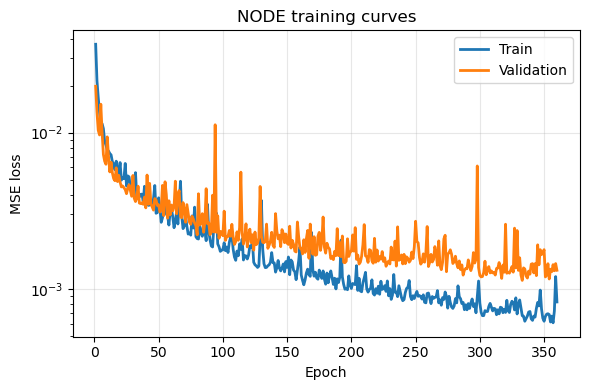

In [32]:
plot_loss_curves(train_losses, val_losses)

In [38]:
import torch
import numpy as np

def build_cnn_node_from_ckpt(ckpt: dict, device: torch.device):
    """
    Robust rebuild for CNN-NODE VelocityNet by inferring architecture from state_dict.
    Works even if you did NOT save dim_gfeat / hidden / base_channels in ckpt.

    Also leaves ckpt['aux'] untouched (if present).
    """
    sd = ckpt["model_state_dict"]

    # --- infer dims from state_dict ---
    if "net.4.bias" not in sd:
        raise KeyError("Could not find 'net.4.bias' in checkpoint. Architecture naming mismatch?")
    D_state = int(sd["net.4.bias"].numel())

    if "net.0.bias" not in sd:
        raise KeyError("Could not find 'net.0.bias' in checkpoint. Architecture naming mismatch?")
    hidden = int(sd["net.0.bias"].numel())

    if "growth_encoder.head.1.bias" not in sd:
        raise KeyError("Could not find 'growth_encoder.head.1.bias' in checkpoint. Architecture naming mismatch?")
    dim_gfeat = int(sd["growth_encoder.head.1.bias"].numel())

    if "growth_encoder.cnn.0.weight" not in sd:
        raise KeyError("Could not find 'growth_encoder.cnn.0.weight' in checkpoint. Architecture naming mismatch?")
    w0 = sd["growth_encoder.cnn.0.weight"]
    base_channels = int(w0.shape[0])
    growth_in_channels = int(w0.shape[1])

    print("[infer CNN-NODE arch]")
    print("  D_state            =", D_state)
    print("  hidden             =", hidden)
    print("  dim_gfeat          =", dim_gfeat)
    print("  growth_in_channels =", growth_in_channels)
    print("  base_channels      =", base_channels)

    # --- optional dims (usually fixed in your code) ---
    dim_sp = int(ckpt.get("dim_sp", 1))
    dim_design = int(ckpt.get("dim_design", 7))
    dim_error = int(ckpt.get("dim_error", 1))
    dim_integral = int(ckpt.get("dim_integral", 1))

    # --- build model (must match your class signature) ---
    model = VelocityNet(
        dim_state=D_state,
        dim_sp=dim_sp,
        dim_design=dim_design,
        dim_error=dim_error,
        dim_integral=dim_integral,
        dim_gfeat=dim_gfeat,
        hidden=hidden,
        growth_in_channels=growth_in_channels,
    ).to(device)

    model.load_state_dict(sd, strict=True)
    model.eval()
    return model


def _coerce_aux_arrays(aux: dict | None) -> dict:
    """
    Convert aux fields like train_sims/val_sims back into numpy arrays for convenience.
    Safe even if aux is missing or partially filled.
    """
    if aux is None:
        return {}

    aux2 = dict(aux)

    for key in ["train_sims", "val_sims"]:
        if key in aux2 and aux2[key] is not None:
            aux2[key] = np.asarray(aux2[key], dtype=np.int64)

    return aux2


def load_model_b_Ag(r_modes: int = 9, device: str | torch.device = "cuda"):
    device = torch.device(device if isinstance(device, str) else device)
    path = f"FINAL_models/Model_B/Model_B_Ag_r{r_modes}_BEST.pt"
    ckpt = torch.load(path, map_location=device)

    model = build_cnn_node_from_ckpt(ckpt, device)

    # ✅ NEW: pull aux (if you saved it) and coerce common fields to arrays
    aux = _coerce_aux_arrays(ckpt.get("aux", None))

    return model, ckpt, aux


# Example:
# model, ckpt, aux = load_model_c2_cnn(r_modes=9, device="cuda")
# print(aux.keys())
# print("n_val:", len(aux["val_sims"]))
# print("first val sims:", aux["val_sims"][:10])


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# new loader returns (model, ckpt, aux)
model, ckpt, aux = load_model_b_Ag(r_modes=9, device=device)

print("Loaded model OK.")
print("Checkpoint keys:", list(ckpt.keys()))
print("Aux present:", bool(aux))

if aux:
    print("Aux keys:", list(aux.keys()))
    if "val_sims" in aux:
        print("n_val sims:", len(aux["val_sims"]))
        print("val_sims sample:", aux["val_sims"][:10])


[infer CNN-NODE arch]
  D_state            = 10
  hidden             = 128
  dim_gfeat          = 16
  growth_in_channels = 2
  base_channels      = 16
Loaded model OK.
Checkpoint keys: ['model_state_dict', 'dt_nominal', 'latent_state_dim', 'input_dim', 'r_modes', 'train_losses', 'val_losses', 'lambda_rollout', 'warmup_epochs', 'n_epochs', 'volume_caps', 'vol_stage_epochs_list', 'frac_new_by_stage', 'lambda_overpred_ag_base', 'lambda_overpred_ag_mult_by_stage', 'z_mean', 'z_std', 'sp_mean', 'sp_std', 'design_mean', 'design_std', 'e_mean', 'e_std', 'I_mean', 'I_std', 'g_mean', 'g_std', 'final_ag_mean', 'final_ag_std']
Aux present: False


In [27]:
r_modes = 9
(
    X_train, Y_train, DT_train, SNAP_train,
    X_val,   Y_val,   DT_val,   SNAP_val,
    D_state, dt_nominal, norm_stats, aux
) = prepare_dataset(r_modes)

print("D_state =", D_state)

  G_field bottom: (42237, 2, 60, 60)  (S,2,H,W) with H=60, W=60
[prepare_dataset r=9] n_sims=927, train_sims=742, val_sims=185
  build_pairs_for_sims: X (33040, 20) Y (33040, 10) DT (33040,) SNAP (33040,) (dt_nominal=1.4)
  build_pairs_for_sims: X (8270, 20) Y (8270, 10) DT (8270,) SNAP (8270,) (dt_nominal=1.4)
D_state = 10


In [28]:
# --- pull what you need from the objects you ALREADY have ---
Z_norm_all    = aux["Z_norm_all"]
G_field_all   = aux["G_field"]
sim_index_all = aux["sim_index"]
time_vals_all = aux["time_vals"]
val_sims      = np.asarray(aux["val_sims"], dtype=np.int64)

device = next(model.parameters()).device
print("device =", device)
print("n_val_sims =", len(val_sims))

device = cpu
n_val_sims = 185


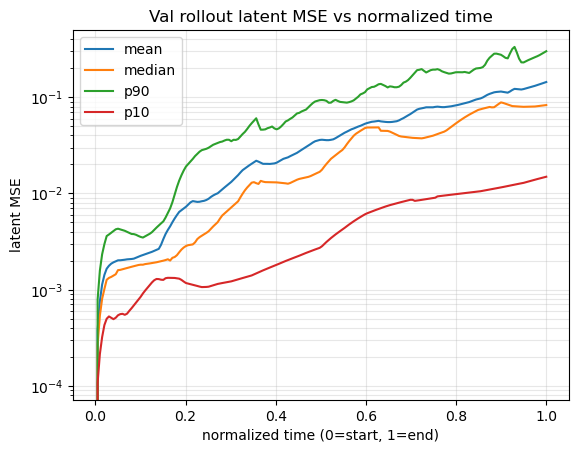

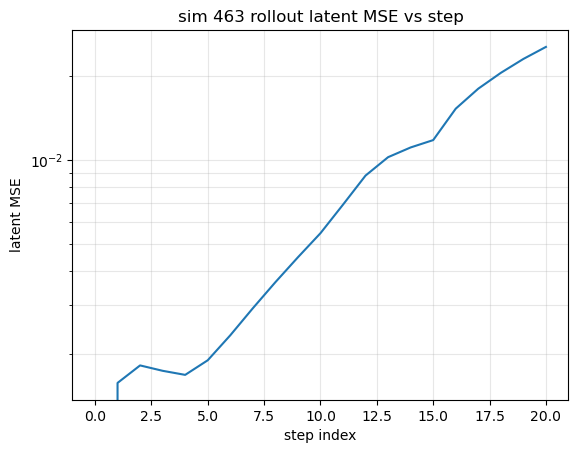

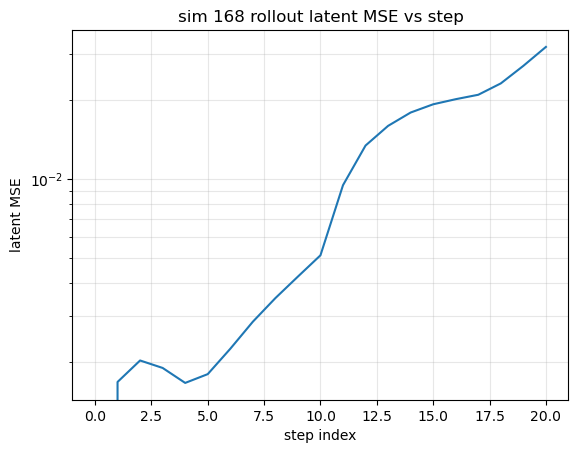

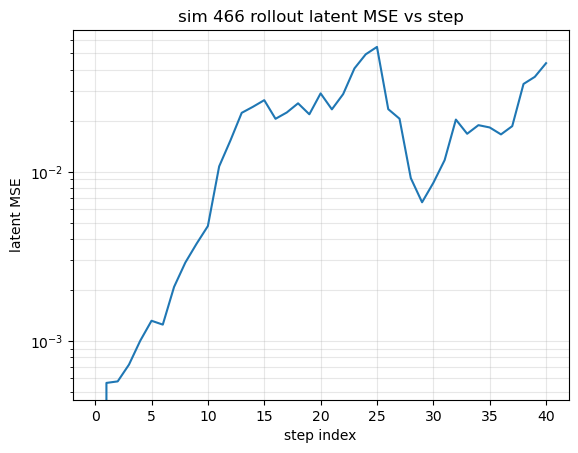

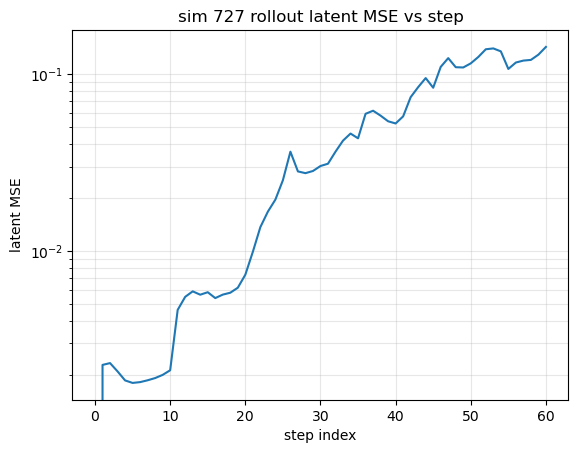

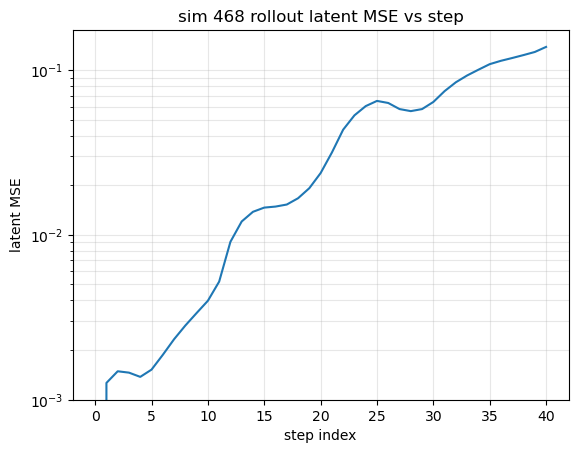

Worst tail-mean MSE (last-k steps):
  sim=73  tail_mean(last5)=5.082e-01  last=6.083e-01
  sim=270  tail_mean(last5)=4.468e-01  last=5.750e-01
  sim=89  tail_mean(last5)=2.978e-01  last=3.337e-01
  sim=34  tail_mean(last5)=2.134e-01  last=2.238e-01
  sim=688  tail_mean(last5)=2.022e-01  last=1.945e-01
  sim=725  tail_mean(last5)=2.014e-01  last=2.512e-01
  sim=315  tail_mean(last5)=1.987e-01  last=1.540e-01
  sim=757  tail_mean(last5)=1.692e-01  last=1.845e-01
  sim=585  tail_mean(last5)=1.592e-01  last=1.781e-01
  sim=727  tail_mean(last5)=1.254e-01  last=1.424e-01


In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def build_snap_to_x_lookup(X_train, SNAP_train, X_val, SNAP_val):
    """
    Build mapping from global snapshot index -> x_base row (full, as used in training).
    SNAP_* entries are the global snapshot indices.
    """
    snap_to_x = {}

    # train
    for x, s in zip(np.asarray(X_train), np.asarray(SNAP_train).astype(int)):
        snap_to_x[int(s)] = np.asarray(x, dtype=np.float32)

    # val (val can overwrite; should be identical anyway)
    for x, s in zip(np.asarray(X_val), np.asarray(SNAP_val).astype(int)):
        snap_to_x[int(s)] = np.asarray(x, dtype=np.float32)

    return snap_to_x


@torch.no_grad()
def rollout_latent_for_sim(
    model,
    sim_id: int,
    *,
    D_state: int,
    device,
    Z_norm_all,
    G_field_all,
    sim_index_all,
    time_vals_all,
    snap_to_x,   # <-- NEW: lookup providing full x_base for each snapshot
):
    sid = int(sim_id)
    idx = np.where(sim_index_all == sid)[0]
    if idx.size == 0:
        raise ValueError(f"No snapshots found for sim_id={sid}")

    t = time_vals_all[idx].astype(float)
    order = np.argsort(t)
    idx_sorted = idx[order]
    t_sorted = t[order]

    Z_true = np.asarray(Z_norm_all[idx_sorted], dtype=np.float32)
    if Z_true.shape[1] < D_state:
        raise ValueError(f"Z_norm_all has dim {Z_true.shape[1]} but D_state={D_state}")

    G_seq = np.asarray(G_field_all[idx_sorted], dtype=np.float32)

    model.eval()

    # init from true
    z_pred = torch.as_tensor(Z_true[0, :D_state], device=device).float()
    Z_pred = [z_pred.detach().cpu().numpy().copy()]

    for n in range(len(idx_sorted) - 1):
        dt = float(t_sorted[n+1] - t_sorted[n])
        if dt <= 0:
            Z_pred.append(z_pred.detach().cpu().numpy().copy())
            continue

        snap_k = int(idx_sorted[n])

        if snap_k not in snap_to_x:
            raise KeyError(f"Snapshot id {snap_k} missing from snap_to_x lookup. "
                           f"Make sure you built it from X_train/X_val + SNAP_train/SNAP_val.")

        # xb_true: full x_base row as used in training
        xb_true = torch.as_tensor(snap_to_x[snap_k], device=device).float().unsqueeze(0)

        # IMPORTANT: replace latent part with current predicted z
        xb_true[:, :D_state] = z_pred.unsqueeze(0)

        Gb = torch.as_tensor(G_seq[n], device=device).float().unsqueeze(0)

        dz = model(xb_true, Gb).squeeze(0)    # (D_state,)
        z_pred = z_pred + dt * dz             # Euler
        Z_pred.append(z_pred.detach().cpu().numpy().copy())

    Z_pred = np.stack(Z_pred, axis=0)
    err = Z_pred - Z_true[:, :D_state]
    mse_t = np.mean(err**2, axis=1)
    return t_sorted, mse_t, Z_true[:, :D_state], Z_pred


def eval_val_rollout_error_over_time(
    model,
    val_sims,
    *,
    D_state: int,
    device,
    Z_norm_all,
    G_field_all,
    sim_index_all,
    time_vals_all,
    snap_to_x,
    n_sims=25,
    seed=0,
    last_k=5,
):
    rng = np.random.default_rng(seed)
    val_sims = np.asarray(val_sims, dtype=np.int64)
    k = int(min(n_sims, val_sims.size))
    pick = rng.choice(val_sims, size=k, replace=False)

    curves = []
    tails  = []
    raw    = []

    for sid in pick:
        t, mse_t, Ztrue, Zpred = rollout_latent_for_sim(
            model, int(sid),
            D_state=D_state,
            device=device,
            Z_norm_all=Z_norm_all,
            G_field_all=G_field_all,
            sim_index_all=sim_index_all,
            time_vals_all=time_vals_all,
            snap_to_x=snap_to_x,
        )
        if len(t) < 2:
            continue

        tau = (t - t[0]) / (t[-1] - t[0] + 1e-12)
        curves.append((tau, mse_t))
        raw.append((int(sid), t, mse_t))

        kk = int(min(last_k, len(mse_t)))
        tails.append((int(sid), float(np.mean(mse_t[-kk:])), float(mse_t[-1]), kk))

    tau_grid = np.linspace(0.0, 1.0, 200)
    M = [np.interp(tau_grid, tau, mse) for (tau, mse) in curves]
    M = np.asarray(M, dtype=np.float64)

    return {
        "tau_grid": tau_grid,
        "mean": M.mean(axis=0),
        "median": np.median(M, axis=0),
        "p25": np.percentile(M, 25, axis=0),
        "p75": np.percentile(M, 75, axis=0),
        "p90": np.percentile(M, 90, axis=0),
        "p10": np.percentile(M, 10, axis=0),
        "tails": tails,
        "raw": raw,
    }


def plot_rollout_error_agg(agg, title="Val rollout latent MSE vs normalized time", n_show_raw=5):
    tau = agg["tau_grid"]

    plt.figure()
    plt.semilogy(tau, agg["mean"], label="mean")
    plt.semilogy(tau, agg["median"], label="median")
    plt.semilogy(tau, agg["p90"], label="p90")
    plt.semilogy(tau, agg["p10"], label="p10")
    plt.xlabel("normalized time (0=start, 1=end)")
    plt.ylabel("latent MSE")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

    for sid, t, mse in agg["raw"][:n_show_raw]:
        plt.figure()
        plt.semilogy(np.arange(len(mse)), mse)
        plt.xlabel("step index")
        plt.ylabel("latent MSE")
        plt.title(f"sim {sid} rollout latent MSE vs step")
        plt.grid(True, which="both", alpha=0.3)
        plt.show()

    tails = sorted(agg["tails"], key=lambda x: x[1], reverse=True)
    print("Worst tail-mean MSE (last-k steps):")
    for sid, tail_mean, last_mse, kk in tails[:10]:
        print(f"  sim={sid}  tail_mean(last{kk})={tail_mean:.3e}  last={last_mse:.3e}")


# --- USE IT ---
snap_to_x = build_snap_to_x_lookup(X_train, SNAP_train, X_val, SNAP_val)

agg = eval_val_rollout_error_over_time(
    model,
    val_sims,
    D_state=D_state,
    device=device,
    Z_norm_all=Z_norm_all,
    G_field_all=G_field_all,
    sim_index_all=sim_index_all,
    time_vals_all=time_vals_all,
    snap_to_x=snap_to_x,
    n_sims=25,
    seed=SEED,
    last_k=5,
)

plot_rollout_error_agg(agg, title="Val rollout latent MSE vs normalized time", n_show_raw=5)

In [30]:
agg = eval_val_rollout_error_over_time(
    model,
    val_sims,
    D_state=D_state,
    device=device,
    Z_norm_all=Z_norm_all,
    G_field_all=G_field_all,
    sim_index_all=sim_index_all,
    time_vals_all=time_vals_all,
    n_sims=25,
    seed=SEED,
    last_k=5,
    build_x_from_snapshot_fn=None,  # set if xb needs extra features
)

plot_rollout_error_agg(agg, title="Val rollout latent MSE vs normalized time", n_show_raw=5)

TypeError: eval_val_rollout_error_over_time() got an unexpected keyword argument 'build_x_from_snapshot_fn'

[infer CNN-NODE arch]
  D_state            = 10
  hidden             = 128
  dim_gfeat          = 16
  growth_in_channels = 2
  base_channels      = 16
Loaded model OK.
Checkpoint keys: ['model_state_dict', 'dt_nominal', 'latent_state_dim', 'input_dim', 'r_modes', 'train_losses', 'val_losses', 'lambda_rollout', 'warmup_epochs', 'n_epochs', 'volume_caps', 'vol_stage_epochs_list', 'frac_new_by_stage', 'lambda_overpred_ag_base', 'lambda_overpred_ag_mult_by_stage', 'z_mean', 'z_std', 'sp_mean', 'sp_std', 'design_mean', 'design_std', 'e_mean', 'e_std', 'I_mean', 'I_std', 'g_mean', 'g_std', 'final_ag_mean', 'final_ag_std']
Aux present: False
